# In Silico `Toxicity` prediction for `BacillusAnthracis` Antibiotic Candidates

This notebook implements a statistically grounded, **FDA-approved-antibiotic-reference-driven** workflow for ranking generated antibiotic candidates using:

- **pPotency (pIC50)** (higher is better)
- **Toxicity burden** (lower is better)
- **ADME feasibility** (higher is better)

The design follows three core ideas from the literature:

1. **QED-style desirability scoring**  
   Heterogeneous properties should first be mapped to a common 0–1 desirability scale and then combined continuously rather than by rigid pass/fail rules.

2. **ADMET-score-style weighted aggregation**  
   ADMET endpoints should not all contribute equally. More informative and clinically important endpoints should get stronger weight.

3. **ADMET-AI reference-based interpretation**  
   ADMET properties are most meaningful when interpreted relative to an appropriate approved-drug reference set.  
   For this project, the most relevant reference set is **FDA-approved antibiotics**.

The goal is to support **early prioritization**, not to make definitive toxicity claims.

## What this notebook does

1. Harmonizes the reference and candidate dataframes
2. Keeps only metadata, potency, toxicity, ADME, and useful physicochemical columns
3. Splits `ADMET-AI` outputs into **Toxicity** and **ADME**
4. Derives **antibiotic-reference-driven statistical weights**
5. Converts each endpoint into a **desirability score**
6. Builds:
   - `ToxicitySafety`
   - `Toxicity Score = 1 - ToxicitySafety`
   - `ADMEFeasibility`
7. Generates:
   - 2D plot: pPotency vs Toxicity burden
   - 3D plot: pPotency vs Toxicity burden vs ADME feasibility
   - Save top-20 candidates to CSV files

In [34]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

import math
import numpy as np
import pandas as pd
import pubchempy as pcp
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem
from admet_ai import ADMETModel
from admet_ai.drugbank import get_drugbank
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from scipy.stats import percentileofscore

## Define data directory for model trained on `ChEMBL + PubChem` bioassay dataset

In [35]:
target_organism = "BacillusAnthracis"

In [36]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
saveDir = os.path.join(dataDir, f"Results/{target_organism}_bestMACAW_allDB/")
os.makedirs(saveDir, exist_ok=True)

### Read `ADMET` endpoints with `pPotency`of the FDA approved Drug data from `Drugbank`

In [97]:
drugBankDrug_FDAapproved_antibiotic_wART_wADMET = pd.read_csv(saveDir + f'{target_organism}_Drugbnk_FDAapproved_Antibiotic_ARTprediction.csv')
# Identify columns that match the string
matched_cols = drugBankDrug_FDAapproved_antibiotic_wART_wADMET.filter(like='drugbank_approved_percentile').columns
# Keep everything EXCEPT those columns
drugBankDrug_FDAapproved_antibiotic_wART_wADMET = drugBankDrug_FDAapproved_antibiotic_wART_wADMET.drop(columns=matched_cols)
max_val = drugBankDrug_FDAapproved_antibiotic_wART_wADMET['pPotency_prediction'].max()
min_val = drugBankDrug_FDAapproved_antibiotic_wART_wADMET['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
drugBankDrug_FDAapproved_antibiotic_wART_wADMET

pPotency_prediction range: 1.343 → 5.897


,smiles,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,Unnamed: 0,ATC_code,...,Clearance_Hepatocyte_AZ,Clearance_Microsome_AZ,Half_Life_Obach,HydrationFreeEnergy_FreeSolv,LD50_Zhu,Lipophilicity_AstraZeneca,PPBR_AZ,Solubility_AqSolDB,VDss_Lombardo,source_DataBase
0,NCC[C@H](O)C(=O)N[C@@H]1C[C@H](N)[C@@H](O[C@H]...,3.525954,1.119518,1.331698,5.720210,0.000298,1.904541e-06,0.046591,0,J01GB;J01RA,...,36.152091,2.245671,7.526745,-20.117337,1.595968,-1.807717,23.987537,-0.102104,-6.522413,FDA_Antibiotics
1,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccc(O)cc3)...,4.987345,1.120375,2.791410,7.183280,0.000010,6.557220e-08,0.001617,1,J01CA;J01CR,...,8.870990,8.964288,-0.649105,-13.895778,1.984036,-0.922387,59.371961,-1.955969,0.402972,FDA_Antibiotics
2,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](NC(=O)N3CCNC3=...,3.442877,1.119518,1.248620,5.637133,0.000361,2.306042e-06,0.056413,4,J01CA;J01CR,...,3.494191,44.284968,1.065897,-13.175952,2.165658,-0.854850,78.940997,-2.968939,2.201075,FDA_Antibiotics
3,C[C@H]1[C@H](NC(=O)/C(=N\OC(C)(C)C(=O)O)c2csc(...,3.786489,1.118681,1.593873,5.979105,0.000163,1.049289e-06,0.025476,5,J01DF,...,-10.878718,0.653251,-1.372036,-15.327836,2.373001,-3.370004,59.166133,-1.183660,5.657260,FDA_Antibiotics
4,CCOC(=O)OC(C)OC(=O)[C@@H]1N2C(=O)[C@@H](NC(=O)...,3.794162,1.118931,1.601058,5.987267,0.000161,1.029753e-06,0.025058,6,J01CA;J01CR,...,100.958985,117.151278,-23.185533,-9.495806,2.714478,2.047164,75.654842,-2.922240,5.521395,FDA_Antibiotics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,4.309461,1.118857,2.116502,6.502420,0.000049,3.144704e-07,0.007647,146,J01AA,...,9.591706,60.994419,11.583123,-12.590552,2.663011,-0.090869,55.730797,-2.513165,5.962830,FDA_Antibiotics
128,CCS(=O)(=O)CCn1c([N+](=O)[O-])cnc1C,4.424298,1.118918,2.231218,6.617377,0.000038,2.413365e-07,0.005872,147,J01RA;J01XD,...,-0.296836,13.442499,-5.683420,-10.941420,1.811951,-0.624001,46.324032,-1.894738,3.686183,FDA_Antibiotics
129,CO[C@H]1C[C@H](O[C@H]2[C@H](C)[C@@H](O[C@@H]3O...,2.276538,1.125678,0.070209,4.482867,0.005290,3.289523e-05,0.850729,150,J01FA,...,107.706804,61.057693,27.990995,-7.253569,2.947751,2.111868,75.170419,-4.023729,8.703718,FDA_Antibiotics
130,N[C@@H]1[C@H]2CN(c3nc4c(cc3F)c(=O)c(C(=O)O)cn4...,3.073553,1.126205,0.866192,5.280915,0.000844,5.237026e-06,0.136084,151,J01MA,...,8.977690,-22.250148,6.670442,-11.224623,2.764096,-0.132504,59.160649,-4.611402,-2.076524,FDA_Antibiotics


### Convert `SMILES` to `Canonical SMILES` for comparison

In [38]:
def canonicalizeSmiles(smilesValue):
    if pd.isna(smilesValue):
        return None

    smilesStr = str(smilesValue).strip()
    if smilesStr == "":
        return None

    mol = Chem.MolFromSmiles(smilesStr)
    if mol is None:
        return None

    return Chem.MolToSmiles(mol, canonical=True)

drugBankDrug_FDAapproved_antibiotic_wART_wADMET = drugBankDrug_FDAapproved_antibiotic_wART_wADMET.copy()
drugBankDrug_FDAapproved_antibiotic_wART_wADMET["smiles"] = (
    drugBankDrug_FDAapproved_antibiotic_wART_wADMET["smiles"].apply(canonicalizeSmiles)
)

drugBankDrug_FDAapproved_antibiotic_wART_wADMET

,smiles,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,Unnamed: 0,ATC_code,...,Clearance_Hepatocyte_AZ,Clearance_Microsome_AZ,Half_Life_Obach,HydrationFreeEnergy_FreeSolv,LD50_Zhu,Lipophilicity_AstraZeneca,PPBR_AZ,Solubility_AqSolDB,VDss_Lombardo,source_DataBase
0,NCC[C@H](O)C(=O)N[C@@H]1C[C@H](N)[C@@H](O[C@H]...,3.525954,1.119518,1.331698,5.720210,0.000298,1.904541e-06,0.046591,0,J01GB;J01RA,...,36.152091,2.245671,7.526745,-20.117337,1.595968,-1.807717,23.987537,-0.102104,-6.522413,FDA_Antibiotics
1,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccc(O)cc3)...,4.987345,1.120375,2.791410,7.183280,0.000010,6.557220e-08,0.001617,1,J01CA;J01CR,...,8.870990,8.964288,-0.649105,-13.895778,1.984036,-0.922387,59.371961,-1.955969,0.402972,FDA_Antibiotics
2,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](NC(=O)N3CCNC3=...,3.442877,1.119518,1.248620,5.637133,0.000361,2.306042e-06,0.056413,4,J01CA;J01CR,...,3.494191,44.284968,1.065897,-13.175952,2.165658,-0.854850,78.940997,-2.968939,2.201075,FDA_Antibiotics
3,C[C@H]1[C@H](NC(=O)/C(=N\OC(C)(C)C(=O)O)c2csc(...,3.786489,1.118681,1.593873,5.979105,0.000163,1.049289e-06,0.025476,5,J01DF,...,-10.878718,0.653251,-1.372036,-15.327836,2.373001,-3.370004,59.166133,-1.183660,5.657260,FDA_Antibiotics
4,CCOC(=O)OC(C)OC(=O)[C@@H]1N2C(=O)[C@@H](NC(=O)...,3.794162,1.118931,1.601058,5.987267,0.000161,1.029753e-06,0.025058,6,J01CA;J01CR,...,100.958985,117.151278,-23.185533,-9.495806,2.714478,2.047164,75.654842,-2.922240,5.521395,FDA_Antibiotics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,4.309461,1.118857,2.116502,6.502420,0.000049,3.144704e-07,0.007647,146,J01AA,...,9.591706,60.994419,11.583123,-12.590552,2.663011,-0.090869,55.730797,-2.513165,5.962830,FDA_Antibiotics
128,CCS(=O)(=O)CCn1c([N+](=O)[O-])cnc1C,4.424298,1.118918,2.231218,6.617377,0.000038,2.413365e-07,0.005872,147,J01RA;J01XD,...,-0.296836,13.442499,-5.683420,-10.941420,1.811951,-0.624001,46.324032,-1.894738,3.686183,FDA_Antibiotics
129,CO[C@H]1C[C@H](O[C@H]2[C@H](C)[C@@H](O[C@@H]3O...,2.276538,1.125678,0.070209,4.482867,0.005290,3.289523e-05,0.850729,150,J01FA,...,107.706804,61.057693,27.990995,-7.253569,2.947751,2.111868,75.170419,-4.023729,8.703718,FDA_Antibiotics
130,N[C@@H]1[C@H]2CN(c3nc4c(cc3F)c(=O)c(C(=O)O)cn4...,3.073553,1.126205,0.866192,5.280915,0.000844,5.237026e-06,0.136084,151,J01MA,...,8.977690,-22.250148,6.670442,-11.224623,2.764096,-0.132504,59.160649,-4.611402,-2.076524,FDA_Antibiotics


### Retain only `toxicity`, `mechanistic`, and `ADME` related endpoints

In [40]:
# Potency-related columns
dataCols = [
    "smiles",
    "ATC_code", "Drug_Type", "source_DataBase"
]

# Potency-related columns
potencyCols = [
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]

# Mechanistic alert endpoints
# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = dataCols + potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in drugBankDrug_FDAapproved_antibiotic_wART_wADMET.columns
]

drugBankDrug_FDAapproved_antibiotic_wART_wADMET = drugBankDrug_FDAapproved_antibiotic_wART_wADMET[selectedCols].copy()

print("Filtered dataframe shape:", drugBankDrug_FDAapproved_antibiotic_wART_wADMET.shape)
drugBankDrug_FDAapproved_antibiotic_wART_wADMET.head()

Filtered dataframe shape: (132, 44)


,smiles,ATC_code,Drug_Type,source_DataBase,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,NCC[C@H](O)C(=O)N[C@@H]1C[C@H](N)[C@@H](O[C@H]...,J01GB;J01RA,antibiotic,FDA_Antibiotics,3.525954,1.119518,1.331698,5.720210,0.000298,1.904541e-06,...,0.038441,0.078183,0.000265,0.007574,0.002886,0.001272,0.016743,0.013290,0.264031,0.002039
1,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccc(O)cc3)...,J01CA;J01CR,antibiotic,FDA_Antibiotics,4.987345,1.120375,2.791410,7.183280,0.000010,6.557220e-08,...,0.024073,0.689159,0.001078,0.006863,0.120056,0.001875,0.029528,0.005839,0.341138,0.002913
2,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](NC(=O)N3CCNC3=...,J01CA;J01CR,antibiotic,FDA_Antibiotics,3.442877,1.119518,1.248620,5.637133,0.000361,2.306042e-06,...,0.029585,0.498562,0.000209,0.003408,0.147586,0.001105,0.014598,0.002810,0.168017,0.003372
3,C[C@H]1[C@H](NC(=O)/C(=N\OC(C)(C)C(=O)O)c2csc(...,J01DF,antibiotic,FDA_Antibiotics,3.786489,1.118681,1.593873,5.979105,0.000163,1.049289e-06,...,0.021248,0.170979,0.000327,0.001936,0.099924,0.000396,0.006895,0.003862,0.107208,0.000714
4,CCOC(=O)OC(C)OC(=O)[C@@H]1N2C(=O)[C@@H](NC(=O)...,J01CA;J01CR,antibiotic,FDA_Antibiotics,3.794162,1.118931,1.601058,5.987267,0.000161,1.029753e-06,...,0.580503,0.481893,0.013029,0.136983,0.067901,0.033108,0.063642,0.114837,0.503432,0.740134


# Check ADMET properties for `buyable` antibiotics

### 1. Read `ART` predicted `pPotency` of all the compounds

In [41]:
BacillusAnthracis_wART_Buyable_predicted_all = pd.read_csv(saveDir + f'{target_organism}_all_Buyable_AntiVirals_ARTprediction.csv')
max_val = BacillusAnthracis_wART_Buyable_predicted_all['pPotency_prediction'].max()
min_val = BacillusAnthracis_wART_Buyable_predicted_all['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
BacillusAnthracis_wART_Buyable_predicted_all

pPotency_prediction range: 1.141 → 6.143


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,4.169872,1.119030,1.976573,6.363170,0.000068,4.333413e-07,0.010554
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,4.429163,1.118621,2.236666,6.621661,0.000037,2.389674e-07,0.005799
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,4.621105,1.118405,2.429031,6.813180,0.000024,1.537519e-07,0.003724
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,4.521367,1.120633,2.324927,6.717807,0.000030,1.915106e-07,0.004732
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,4.643503,1.119350,2.449576,6.837430,0.000023,1.454020e-07,0.003552
...,...,...,...,...,...,...,...,...
59733,Nc1nc(Nc2ccccc2F)nc2ccccc12,4.008815,1.118924,1.815724,6.201907,0.000098,6.281934e-07,0.015285
59734,CNc1nc(Nc2ccccc2F)nc2ccccc12,4.196679,1.119485,2.002488,6.390870,0.000064,4.065651e-07,0.009943
59735,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,4.423288,1.119218,2.229622,6.616955,0.000038,2.415712e-07,0.005894
59736,CNc1nc(Nc2ccccc2Cl)nc2ccccc12,4.833275,1.121137,2.635845,7.030704,0.000015,9.317435e-08,0.002313


### plot `pPotency` distribution with error bars

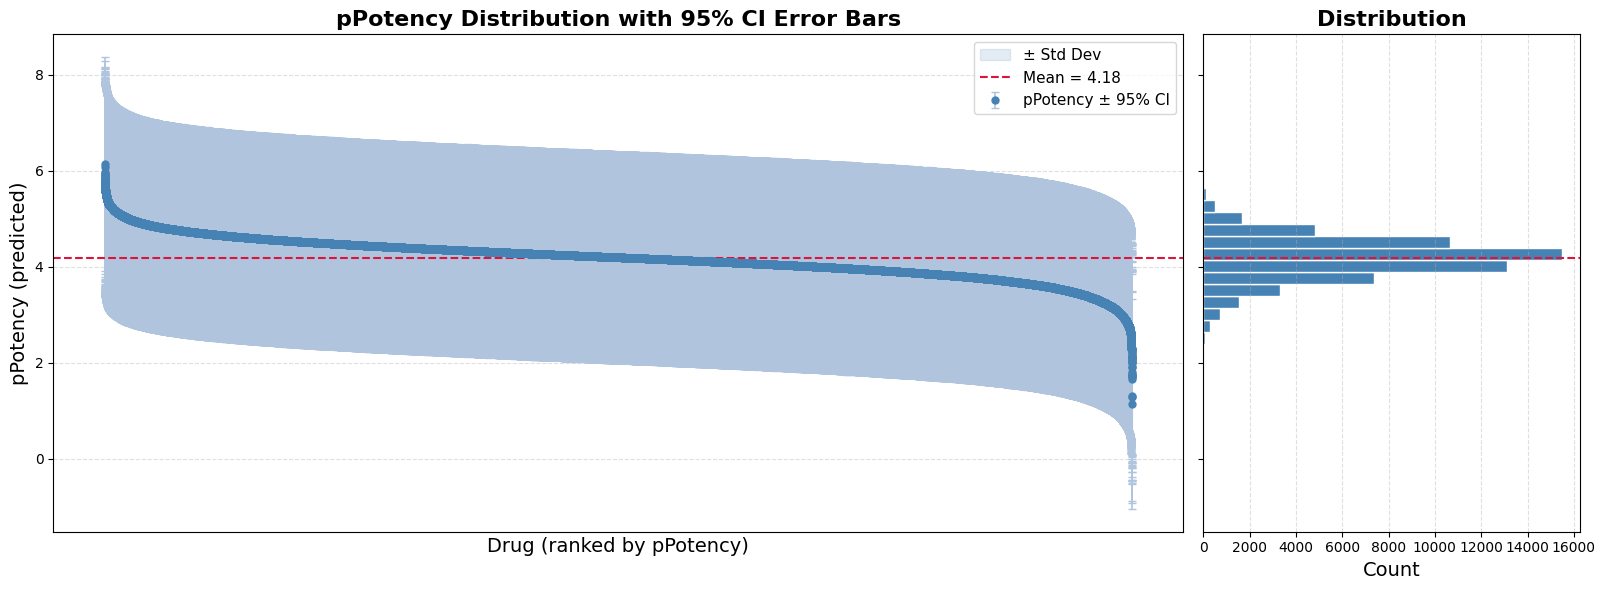

In [70]:
ppotencyDF = BacillusAnthracis_wART_Buyable_predicted_all.sort_values(
    "pPotency_prediction", ascending=False).reset_index(drop=True)

x = np.arange(len(ppotencyDF))
pred = ppotencyDF["pPotency_prediction"]
yerr = np.array([pred - ppotencyDF["pPotency_lower_95CI"],
                 ppotencyDF["pPotency_upper_95CI"] - pred])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6),
                                gridspec_kw={"width_ratios": [3, 1]}, sharey=True)

# ── Scatter + error bars ──────────────────────────────────────────────────────
ax1.errorbar(x, pred, yerr=yerr, fmt='o', color='steelblue', ecolor='lightsteelblue',
             elinewidth=1.2, capsize=3, markersize=5, alpha=1, label="pPotency ± 95% CI")
ax1.fill_between(x, pred - ppotencyDF["pPotency_std"], pred + ppotencyDF["pPotency_std"],
                 alpha=0.15, color='steelblue', label="± Std Dev")
ax1.axhline(pred.mean(),   color='crimson',    linestyle='--', linewidth=1.5, label=f'Mean = {pred.mean():.2f}')
#ax1.axhline(pred.median(), color='darkorange', linestyle=':',  linewidth=1.5, label=f'Median = {pred.median():.2f}')
ax1.set_xlabel("Drug (ranked by pPotency)", fontsize=14)  
ax1.set_ylabel("pPotency (predicted)",      fontsize=14) 
ax1.set_title("pPotency Distribution with 95% CI Error Bars", fontsize=16, fontweight='bold')  
ax1.set_xticks([])
ax1.legend(fontsize=11); ax1.grid(axis='y', linestyle='--', alpha=0.4)

# ── Histogram ─────────────────────────────────────────────────────────────────
ax2.hist(pred, bins=20, orientation='horizontal', color='steelblue', edgecolor='white', alpha=1)
ax2.axhline(pred.mean(),   color='crimson',    linestyle='--', linewidth=1.5)
#ax2.axhline(pred.median(), color='darkorange', linestyle=':',  linewidth=1.5)
ax2.set_xlabel("Count", fontsize=14)        
ax2.set_title("Distribution", fontsize=16, fontweight='bold') 
ax2.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_distribution_buyable.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_distribution_buyable.png")
plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### Read predicted `ADMET` properties for all candidate SMILES

In [42]:
BacillusAnthracis_wART_BuyableDataset_predicted_all_wToxicity = pd.read_csv(saveDir + f'{target_organism}_all_Buyable_AntiVirals_ARTprediction_wToxicity.csv')
# Identify columns that match the string
matched_cols = BacillusAnthracis_wART_BuyableDataset_predicted_all_wToxicity.filter(like='drugbank_approved_percentile').columns
# Keep everything EXCEPT those columns
BacillusAnthracis_wART_BuyableDataset_predicted_all_wToxicity = BacillusAnthracis_wART_BuyableDataset_predicted_all_wToxicity.drop(columns=matched_cols)
max_val = BacillusAnthracis_wART_BuyableDataset_predicted_all_wToxicity['pPotency_prediction'].max()
min_val = BacillusAnthracis_wART_BuyableDataset_predicted_all_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
BacillusAnthracis_wART_BuyableDataset_predicted_all_wToxicity

pPotency_prediction range: 1.141 → 6.143


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang,Clearance_Hepatocyte_AZ,Clearance_Microsome_AZ,Half_Life_Obach,HydrationFreeEnergy_FreeSolv,LD50_Zhu,Lipophilicity_AstraZeneca,PPBR_AZ,Solubility_AqSolDB,VDss_Lombardo
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,4.169872,1.119030,1.976573,6.363170,0.000068,4.333413e-07,0.010554,374.397,3.12552,...,-4.996861,118.607335,86.303194,0.484340,-5.984115,1.914311,3.002084,94.922207,-4.558344,11.722148
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,4.429163,1.118621,2.236666,6.621661,0.000037,2.389674e-07,0.005799,338.393,1.33666,...,-5.205537,42.327284,39.116500,-49.647802,-12.707386,1.809286,0.972791,88.427560,-3.252773,-1.914700
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,4.621105,1.118405,2.429031,6.813180,0.000024,1.537519e-07,0.003724,384.454,0.45232,...,-4.945433,105.007035,66.163495,-46.032595,-10.459297,1.995207,0.321122,71.043233,-2.603080,2.197672
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,4.521367,1.120633,2.324927,6.717807,0.000030,1.915106e-07,0.004732,346.416,1.90460,...,-5.257053,46.138803,3.781762,13.823905,-12.008407,2.166125,0.133414,70.917933,-2.653811,-3.392723
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,4.643503,1.119350,2.449576,6.837430,0.000023,1.454020e-07,0.003552,341.772,2.47350,...,-5.546406,9.270344,-16.773551,2.057861,-10.951267,2.766361,-0.750541,102.927616,-2.586969,-4.161391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46934,CNc1nc(Nc2ccccc2)nc2ccccc12,4.172397,1.119743,1.977701,6.367093,0.000067,4.294444e-07,0.010527,250.305,3.41510,...,-4.581137,94.550676,95.965427,67.867081,-9.766103,2.180136,3.347163,96.571909,-4.436477,9.117796
46935,Nc1nc(Nc2ccccc2F)nc2ccccc12,4.008815,1.118924,1.815724,6.201907,0.000098,6.281934e-07,0.015285,254.268,3.09470,...,-4.770010,66.496145,68.586421,27.236041,-11.552250,2.847540,2.901858,89.781617,-3.546711,1.054114
46936,CNc1nc(Nc2ccccc2F)nc2ccccc12,4.196679,1.119485,2.002488,6.390870,0.000064,4.065651e-07,0.009943,268.295,3.55420,...,-4.600024,88.097798,100.868810,55.791207,-10.121322,2.605350,3.409929,95.274537,-4.294779,2.445678
46937,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,4.423288,1.119218,2.229622,6.616955,0.000038,2.415712e-07,0.005894,270.723,3.60900,...,-4.658278,84.763380,81.986052,54.174968,-11.344900,2.844284,3.144153,93.304396,-4.252212,11.537782


### 2. Antibiotic candidate prioritization by comparing with `Drugbank`

In [43]:
refDrugbankDF = drugBankDrug_FDAapproved_antibiotic_wART_wADMET.copy()
generatedCandidateDF = BacillusAnthracis_wART_BuyableDataset_predicted_all_wToxicity.copy()

print("Drugbank reference dataframe shape:", refDrugbankDF.shape)
print("Generated candidate dataframe shape:", generatedCandidateDF.shape)

Drugbank reference dataframe shape: (132, 44)
Generated candidate dataframe shape: (46939, 57)


### 3. Harmonize metadata and the SMILES column

The candidate dataframe may use `SMILES` instead of `smiles`.  
This cell standardizes that and fills a few metadata fields if they are missing.

In [44]:
if "SMILES" in generatedCandidateDF.columns:
    generatedCandidateDF = generatedCandidateDF.rename(columns={"SMILES": "smiles"})

if "ATC_code" not in generatedCandidateDF.columns:
    generatedCandidateDF["ATC_code"] = pd.NA

if "Drug_Type" not in generatedCandidateDF.columns:
    generatedCandidateDF["Drug_Type"] = "Predicted_candidate"

if "source_DataBase" not in generatedCandidateDF.columns:
    generatedCandidateDF["source_DataBase"] = "Generated"

refDrugbankDF["datasetLabel"] = "FDA-approved antibiotics"
generatedCandidateDF["datasetLabel"] = "Generated candidates"

print("smiles in refDrugbankDF:", "smiles" in refDrugbankDF.columns)
print("smiles in generatedCandidateDF:", "smiles" in generatedCandidateDF.columns)

smiles in refDrugbankDF: True
smiles in generatedCandidateDF: True


### 4. Define `ADMET` column groups

We keep:
- metadata
- potency-related columns
- toxicity-related columns
- ADME-related columns
- a few physicochemical property columns such as `QED`, `logP` and `molecular_weight`

In [45]:
metadataCols = [
    "smiles",
    "ATC_code",
    "Drug_Type",
    "source_DataBase",
    "datasetLabel",
]

potencyCols = [
    "pPotency_prediction",
    "pPotency_std",
    "pPotency_lower_95CI",
    "pPotency_upper_95CI",
    "IC50(M)_prediction",
    "IC50(M)_lower_95CI",
    "IC50(M)_upper_95CI",
]

toxicityCols = [
    "AMES",
    "Carcinogens_Lagunin",
    "ClinTox",
    "DILI",
    "Skin_Reaction",
    "hERG",
    "LD50_Zhu",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma",
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
]

admeCols = [
    "Bioavailability_Ma",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Caco2_Wang",
    "Solubility_AqSolDB",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith",
    "Pgp_Broccatelli",
    "Clearance_Hepatocyte_AZ",
    "Clearance_Microsome_AZ",
    "Half_Life_Obach",
    "PPBR_AZ",
    "VDss_Lombardo",
]

optionalCols = ["BBB_Martins"]

physicochemCols = [
    "molecular_weight",
    "logP",
    "hydrogen_bond_acceptors",
    "hydrogen_bond_donors",
    "Lipinski",
    "QED",
    "stereo_centers",
    "tpsa",
    "HydrationFreeEnergy_FreeSolv",
    "Lipophilicity_AstraZeneca",
]

keepCols = list(dict.fromkeys(metadataCols + potencyCols + toxicityCols + admeCols + optionalCols + physicochemCols))
print("Total kept columns:", len(keepCols))

Total kept columns: 61


### 5. Build aligned reference and candidate dataframes

This cell keeps the same columns in both dataframes and creates any missing columns as `NaN`

In [46]:
def ensureCols(DF, colList):
    outDF = DF.copy()
    for colName in colList:
        if colName not in outDF.columns:
            outDF[colName] = np.nan
    return outDF[colList].copy()

refScoreDF = ensureCols(refDrugbankDF, keepCols)
candScoreDF = ensureCols(generatedCandidateDF, keepCols)

print("Reference aligned shape:", refScoreDF.shape)
print("Candidate aligned shape:", candScoreDF.shape)

Reference aligned shape: (132, 61)
Candidate aligned shape: (46939, 61)


### 6. Convert relevant columns to numeric

All scoring-related columns are converted to numeric.  

In [47]:
numericCols = list(dict.fromkeys(potencyCols + toxicityCols + admeCols + optionalCols + physicochemCols))

for colName in numericCols:
    if colName in refScoreDF.columns:
        refScoreDF[colName] = pd.to_numeric(refScoreDF[colName], errors="coerce")
    if colName in candScoreDF.columns:
        candScoreDF[colName] = pd.to_numeric(candScoreDF[colName], errors="coerce")

refScoreDF["potencyConservative"] = refScoreDF["pPotency_lower_95CI"].fillna(refScoreDF["pPotency_prediction"])
candScoreDF["potencyConservative"] = candScoreDF["pPotency_lower_95CI"].fillna(candScoreDF["pPotency_prediction"])

### 7. Define endpoint metadata

This table contains:
- endpoint name
- whether it belongs to the **toxicity** or **adme** group
- the direction of desirability:
  - `lowerBetter`
  - `higherBetter`
  - `referenceMatch`


In [48]:
endpointMetaDF = pd.DataFrame([
    # Toxicity
    {"endpoint": "AMES",                "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "Carcinogens_Lagunin", "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "ClinTox",             "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "DILI",                "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "Skin_Reaction",       "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "hERG",                "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "LD50_Zhu",            "majorGroup": "toxicity", "direction": "higherBetter"},
    {"endpoint": "NR-AR-LBD",           "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-AR",               "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-AhR",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-Aromatase",        "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-ER-LBD",           "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-ER",               "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-PPAR-gamma",       "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-ARE",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-ATAD5",            "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-HSE",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-MMP",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-p53",              "majorGroup": "toxicity", "direction": "lowerBetter"},

    # ADME
    {"endpoint": "Bioavailability_Ma",             "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "HIA_Hou",                        "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "PAMPA_NCATS",                    "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "Caco2_Wang",                     "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "Solubility_AqSolDB",             "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "CYP1A2_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP2C19_Veith",                  "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP2C9_Substrate_CarbonMangels", "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "CYP2C9_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP2D6_Substrate_CarbonMangels", "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "CYP2D6_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP3A4_Substrate_CarbonMangels", "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "CYP3A4_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "Pgp_Broccatelli",                "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "Clearance_Hepatocyte_AZ",        "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "Clearance_Microsome_AZ",         "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "Half_Life_Obach",                "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "PPBR_AZ",                        "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "VDss_Lombardo",                  "majorGroup": "adme", "direction": "referenceMatch"},
])

endpointMetaDF

,endpoint,majorGroup,direction
0,AMES,toxicity,lowerBetter
1,Carcinogens_Lagunin,toxicity,lowerBetter
2,ClinTox,toxicity,lowerBetter
3,DILI,toxicity,lowerBetter
4,Skin_Reaction,toxicity,lowerBetter
5,hERG,toxicity,lowerBetter
6,LD50_Zhu,toxicity,higherBetter
7,NR-AR-LBD,toxicity,lowerBetter
8,NR-AR,toxicity,lowerBetter
9,NR-AhR,toxicity,lowerBetter


### 8. Derive fully statistical endpoint weights from FDA-approved antibiotics from `Drugbank`

For each endpoint we compute:

- **informativeness** = inverse of the reference IQR  
  A tighter approved-antibiotic distribution means the endpoint is more constrained and therefore more informative.

- **uniqueness** = inverse redundancy penalty  
  Endpoints that are highly correlated with other endpoints in the same group get reduced weight.

The final endpoint weights are normalized inside each major group:
- `toxicity`
- `adme`

In [49]:
def robustIQR(series):
    cleanSeries = pd.to_numeric(series, errors="coerce").dropna()
    if len(cleanSeries) < 5:
        return np.nan
    q25, q75 = np.percentile(cleanSeries, [25, 75])
    return q75 - q25

weightRows = []

for majorGroupName in endpointMetaDF["majorGroup"].unique():
    groupMetaDF = endpointMetaDF[endpointMetaDF["majorGroup"] == majorGroupName].copy()
    groupEndpoints = groupMetaDF["endpoint"].tolist()

    groupRefDF = refScoreDF[groupEndpoints].apply(pd.to_numeric, errors="coerce")
    groupCorrDF = groupRefDF.corr().abs()

    for endpointName in groupEndpoints:
        series = groupRefDF[endpointName]
        iqrValue = robustIQR(series)

        informativeness = 1.0 / (iqrValue + 1e-6) if pd.notna(iqrValue) else 1.0

        otherEndpoints = [x for x in groupEndpoints if x != endpointName]
        if len(otherEndpoints) > 0 and endpointName in groupCorrDF.index:
            meanAbsCorr = groupCorrDF.loc[endpointName, otherEndpoints].dropna().mean()
            uniqueness = max(1.0 - meanAbsCorr, 1e-3) if pd.notna(meanAbsCorr) else 1.0
        else:
            uniqueness = 1.0

        rawWeight = informativeness * uniqueness

        weightRows.append({
            "endpoint": endpointName,
            "majorGroup": majorGroupName,
            "direction": groupMetaDF.loc[groupMetaDF["endpoint"] == endpointName, "direction"].iloc[0],
            "iqrValue": iqrValue,
            "informativeness": informativeness,
            "uniqueness": uniqueness,
            "rawWeight": rawWeight,
        })

weightDF = pd.DataFrame(weightRows)
weightDF["finalWeight"] = (
    weightDF.groupby("majorGroup")["rawWeight"]
    .transform(lambda x: x / x.sum())
)

weightDF.sort_values(["majorGroup", "finalWeight"], ascending=[True, False])

,endpoint,majorGroup,direction,iqrValue,informativeness,uniqueness,rawWeight,finalWeight
24,CYP1A2_Veith,adme,lowerBetter,0.007583,131.856666,0.875912,115.494897,0.374049
27,CYP2C9_Veith,adme,lowerBetter,0.015054,66.424005,0.743478,49.384762,0.159941
29,CYP2D6_Veith,adme,lowerBetter,0.023108,43.273037,0.852122,36.873917,0.119422
25,CYP2C19_Veith,adme,lowerBetter,0.020200,49.501684,0.716789,35.482260,0.114915
28,CYP2D6_Substrate_CarbonMangels,adme,referenceMatch,0.027401,36.494317,0.742754,27.106292,0.087788
31,CYP3A4_Veith,adme,lowerBetter,0.048597,20.577056,0.715226,14.717253,0.047664
32,Pgp_Broccatelli,adme,referenceMatch,0.087841,11.384115,0.775158,8.824486,0.028580
26,CYP2C9_Substrate_CarbonMangels,adme,referenceMatch,0.105874,9.445118,0.747599,7.061157,0.022869
30,CYP3A4_Substrate_CarbonMangels,adme,referenceMatch,0.278713,3.587905,0.749184,2.688000,0.008706
21,PAMPA_NCATS,adme,higherBetter,0.311315,3.212166,0.586158,1.882835,0.006098


### 9. Helper functions for desirability scoring and weighted aggregation

This section defines:

- percentile-based desirability functions
- a reference-matching desirability function
- weighted geometric mean aggregation

In [50]:
def getSortedRefArray(refSeries):
    refArray = pd.to_numeric(refSeries, errors="coerce").dropna().to_numpy(dtype=float)
    refArray = refArray[np.isfinite(refArray)]
    refArray = np.sort(refArray)
    return refArray

def higherBetterDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan, dtype=float)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    finiteMask = np.isfinite(valueArray)
    percentArray = np.searchsorted(refArray, valueArray[finiteMask], side="right") / len(refArray)
    outArray[finiteMask] = np.clip(percentArray, 0.0, 1.0)
    return pd.Series(outArray, index=valueSeries.index)

def lowerBetterDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan, dtype=float)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    finiteMask = np.isfinite(valueArray)
    percentArray = np.searchsorted(refArray, valueArray[finiteMask], side="right") / len(refArray)
    outArray[finiteMask] = np.clip(1.0 - percentArray, 0.0, 1.0)
    return pd.Series(outArray, index=valueSeries.index)

def referenceMatchDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan, dtype=float)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    refMedian = np.nanmedian(refArray)
    q25, q75 = np.nanpercentile(refArray, [25, 75])
    robustSigma = (q75 - q25) / 1.349 if q75 > q25 else np.nanstd(refArray)

    if not np.isfinite(robustSigma) or robustSigma <= 0:
        robustSigma = 1e-6

    finiteMask = np.isfinite(valueArray)
    zArray = (valueArray[finiteMask] - refMedian) / robustSigma
    outArray[finiteMask] = np.exp(-0.5 * (zArray ** 2))
    outArray = np.clip(outArray, 0.0, 1.0)

    return pd.Series(outArray, index=valueSeries.index)

def weightedGeoMeanSeries(DF, valueColList, weightSeries):
    valueMatrix = DF[valueColList].to_numpy(dtype=float)
    weightArray = np.asarray(weightSeries, dtype=float)
    outArray = np.full(valueMatrix.shape[0], np.nan, dtype=float)

    for rowIdx in range(valueMatrix.shape[0]):
        rowArray = valueMatrix[rowIdx]
        finiteMask = np.isfinite(rowArray)

        if finiteMask.sum() == 0:
            continue

        rowValues = np.clip(rowArray[finiteMask], 1e-6, 1.0)
        rowWeights = weightArray[finiteMask]
        outArray[rowIdx] = np.exp(np.sum(rowWeights * np.log(rowValues)) / np.sum(rowWeights))

    return pd.Series(outArray, index=DF.index)

### 10. Convert endpoints into 0–1 desirability scores

Every endpoint becomes a new `*_des` column.
We also compute `PotencyDesRaw` from the reference antibiotic potency distribution.

In [51]:
for _, rowDF in weightDF.iterrows():
    endpointName = rowDF["endpoint"]
    directionName = rowDF["direction"]
    desCol = f"{endpointName}_des"

    if directionName == "higherBetter":
        refScoreDF[desCol] = higherBetterDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desCol] = higherBetterDes(refScoreDF[endpointName], candScoreDF[endpointName])

    elif directionName == "lowerBetter":
        refScoreDF[desCol] = lowerBetterDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desCol] = lowerBetterDes(refScoreDF[endpointName], candScoreDF[endpointName])

    elif directionName == "referenceMatch":
        refScoreDF[desCol] = referenceMatchDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desCol] = referenceMatchDes(refScoreDF[endpointName], candScoreDF[endpointName])

refScoreDF["PotencyDesRaw"] = higherBetterDes(
    refScoreDF["pPotency_prediction"],
    refScoreDF["pPotency_prediction"]
)

candScoreDF["PotencyDesRaw"] = higherBetterDes(
    refScoreDF["pPotency_prediction"],
    candScoreDF["pPotency_prediction"]
)
refScoreDF

,smiles,ATC_code,Drug_Type,source_DataBase,datasetLabel,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,...,CYP2D6_Veith_des,CYP3A4_Substrate_CarbonMangels_des,CYP3A4_Veith_des,Pgp_Broccatelli_des,Clearance_Hepatocyte_AZ_des,Clearance_Microsome_AZ_des,Half_Life_Obach_des,PPBR_AZ_des,VDss_Lombardo_des,PotencyDesRaw
0,NCC[C@H](O)C(=O)N[C@@H]1C[C@H](N)[C@@H](O[C@H]...,J01GB;J01RA,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,3.525954,1.119518,1.331698,5.720210,0.000298,...,0.477273,0.972613,0.818182,9.681491e-01,NaN,NaN,NaN,NaN,NaN,0.378788
1,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccc(O)cc3)...,J01CA;J01CR,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,4.987345,1.120375,2.791410,7.183280,0.000010,...,0.674242,0.830805,0.780303,9.318440e-01,NaN,NaN,NaN,NaN,NaN,0.977273
2,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](NC(=O)N3CCNC3=...,J01CA;J01CR,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,3.442877,1.119518,1.248620,5.637133,0.000361,...,0.825758,0.974109,0.765152,9.540457e-01,NaN,NaN,NaN,NaN,NaN,0.340909
3,C[C@H]1[C@H](NC(=O)/C(=N\OC(C)(C)C(=O)O)c2csc(...,J01DF,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,3.786489,1.118681,1.593873,5.979105,0.000163,...,0.750000,0.872005,0.893939,9.876953e-01,NaN,NaN,NaN,NaN,NaN,0.454545
4,CCOC(=O)OC(C)OC(=O)[C@@H]1N2C(=O)[C@@H](NC(=O)...,J01CA;J01CR,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,3.794162,1.118931,1.601058,5.987267,0.000161,...,0.022727,0.378266,0.030303,2.050005e-01,NaN,NaN,NaN,NaN,NaN,0.469697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,J01AA,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,4.309461,1.118857,2.116502,6.502420,0.000049,...,0.189394,0.214633,0.371212,5.888156e-01,NaN,NaN,NaN,NaN,NaN,0.810606
128,CCS(=O)(=O)CCn1c([N+](=O)[O-])cnc1C,J01RA;J01XD,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,4.424298,1.118918,2.231218,6.617377,0.000038,...,0.931818,0.066655,0.856061,8.940999e-01,NaN,NaN,NaN,NaN,NaN,0.878788
129,CO[C@H]1C[C@H](O[C@H]2[C@H](C)[C@@H](O[C@@H]3O...,J01FA,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,2.276538,1.125678,0.070209,4.482867,0.005290,...,0.462121,0.078071,0.022727,2.447435e-41,NaN,NaN,NaN,NaN,NaN,0.068182
130,N[C@@H]1[C@H]2CN(c3nc4c(cc3F)c(=O)c(C(=O)O)cn4...,J01MA,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,3.073553,1.126205,0.866192,5.280915,0.000844,...,0.151515,0.847208,0.522727,9.819411e-01,NaN,NaN,NaN,NaN,NaN,0.265152


### 11. Directly aggregate within the two separate ADMET groups

This notebook uses:
- one direct **toxicity** aggregate
- one direct **adme** aggregate

Then we define:
- `ToxicitySafety`
- `Toxicity Score = 1 - ToxicitySafety`
- `ADMEFeasibility`

In [52]:
toxWeightDF = weightDF[weightDF["majorGroup"] == "toxicity"].copy()
admeWeightDF = weightDF[weightDF["majorGroup"] == "adme"].copy()

toxDesCols = [f"{endpointName}_des" for endpointName in toxWeightDF["endpoint"]]
admeDesCols = [f"{endpointName}_des" for endpointName in admeWeightDF["endpoint"]]

refScoreDF["ToxicitySafety"] = weightedGeoMeanSeries(
    refScoreDF,
    toxDesCols,
    toxWeightDF["finalWeight"]
)
candScoreDF["ToxicitySafety"] = weightedGeoMeanSeries(
    candScoreDF,
    toxDesCols,
    toxWeightDF["finalWeight"]
)

refScoreDF["ADMEFeasibility"] = weightedGeoMeanSeries(
    refScoreDF,
    admeDesCols,
    admeWeightDF["finalWeight"]
)
candScoreDF["ADMEFeasibility"] = weightedGeoMeanSeries(
    candScoreDF,
    admeDesCols,
    admeWeightDF["finalWeight"]
)

refScoreDF["coreToxicityScore"] = 1.0 - refScoreDF["ToxicitySafety"]
candScoreDF["coreToxicityScore"] = 1.0 - candScoreDF["ToxicitySafety"]

refScoreDF["ToxicityBurden"] = refScoreDF["coreToxicityScore"]
candScoreDF["ToxicityBurden"] = candScoreDF["coreToxicityScore"]

refScoreDF[["pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"]].describe().T

,count,mean,std,min,25%,50%,75%,max
pPotency_prediction,132.0,3.684012,0.821362,1.343247,3.046390,3.928463,4.233035,5.897288
coreToxicityScore,132.0,0.570184,0.217179,0.162787,0.405250,0.589680,0.734321,0.998633
ADMEFeasibility,132.0,0.442508,0.239315,0.002264,0.262605,0.418293,0.628735,0.939134


## 12. Inspect the statistically derived endpoint weights

In [53]:
weightDF.sort_values(["majorGroup", "finalWeight"], ascending=[True, False])

,endpoint,majorGroup,direction,iqrValue,informativeness,uniqueness,rawWeight,finalWeight
24,CYP1A2_Veith,adme,lowerBetter,0.007583,131.856666,0.875912,115.494897,0.374049
27,CYP2C9_Veith,adme,lowerBetter,0.015054,66.424005,0.743478,49.384762,0.159941
29,CYP2D6_Veith,adme,lowerBetter,0.023108,43.273037,0.852122,36.873917,0.119422
25,CYP2C19_Veith,adme,lowerBetter,0.020200,49.501684,0.716789,35.482260,0.114915
28,CYP2D6_Substrate_CarbonMangels,adme,referenceMatch,0.027401,36.494317,0.742754,27.106292,0.087788
31,CYP3A4_Veith,adme,lowerBetter,0.048597,20.577056,0.715226,14.717253,0.047664
32,Pgp_Broccatelli,adme,referenceMatch,0.087841,11.384115,0.775158,8.824486,0.028580
26,CYP2C9_Substrate_CarbonMangels,adme,referenceMatch,0.105874,9.445118,0.747599,7.061157,0.022869
30,CYP3A4_Substrate_CarbonMangels,adme,referenceMatch,0.278713,3.587905,0.749184,2.688000,0.008706
21,PAMPA_NCATS,adme,higherBetter,0.311315,3.212166,0.586158,1.882835,0.006098


### 13. Plot: `high pPotency` and `low Toxicity Score`

Selection rule:
- pPotency in the top quartile of generated compounds
- Toxicity Score in the bottom quartile of generated compounds

Within that selected region, ranking uses the geometric mean of:
- `PotencyDesRaw`
- `ToxicitySafety`

In [54]:
cand2DDF = candScoreDF.copy()

cand2DDF = cand2DDF[
    cand2DDF[["pPotency_prediction", "coreToxicityScore", "ToxicitySafety", "PotencyDesRaw"]]
    .notna()
    .all(axis=1)
].copy()

xCutoff2D = cand2DDF["pPotency_prediction"].quantile(0.75)
yCutoff2D = cand2DDF["coreToxicityScore"].quantile(0.25)

optimal2DDF = cand2DDF[
    (cand2DDF["pPotency_prediction"] >= xCutoff2D) &
    (cand2DDF["coreToxicityScore"] <= yCutoff2D)
].copy()

optimal2DDF["OverallPriority2D"] = np.sqrt(
    optimal2DDF["PotencyDesRaw"] * optimal2DDF["ToxicitySafety"]
)

top20_2D_DF = optimal2DDF.sort_values(
    by=["OverallPriority2D", "pPotency_prediction", "coreToxicityScore"],
    ascending=[False, False, True]
).head(20).copy()

top20_2D_DF["Top20Rank_2D"] = np.arange(1, len(top20_2D_DF) + 1)

top20_2D_DF[
    [
        "Top20Rank_2D",
        "smiles",
        "pPotency_prediction",
        "pPotency_std",
        "pPotency_lower_95CI",
        "coreToxicityScore",
        "ToxicitySafety",
        "OverallPriority2D",
        "QED",
    ]
]

,Top20Rank_2D,smiles,pPotency_prediction,pPotency_std,pPotency_lower_95CI,coreToxicityScore,ToxicitySafety,OverallPriority2D,QED
18283,1,COc1ccc(S(=O)(=O)NC(=O)C2CCOCC2)cc1,4.938421,1.119496,2.744210,0.107247,0.892753,0.926789,0.894027
10949,2,CNC(=O)NC1CCN(CC2(C)CN(Cc3ccccc3)C2=O)CC1,5.081690,1.124261,2.878139,0.126384,0.873616,0.923992,0.794432
4738,3,COC(=O)C1CCC2(CC1)CC(=O)N2,4.502238,1.118620,2.309742,0.081125,0.918875,0.913970,0.494654
12709,4,CCn1ccnc1CN1CCN(CCCS(N)(=O)=O)CC1,4.732647,1.120267,2.536924,0.116777,0.883223,0.910875,0.746592
29416,5,CCc1cc(NS(=O)(=O)c2cnn(CC)c2)nc(C)n1,4.549990,1.119508,2.355755,0.095437,0.904563,0.910595,0.899297
12708,6,Cc1nc(C)n(CC2CCCCN2CCCS(N)(=O)=O)n1,4.551219,1.119039,2.357903,0.096983,0.903017,0.909816,0.821215
17121,7,COC(=O)N1CCCC1C(=O)NS(=O)(=O)c1ccc(F)cc1F,4.902949,1.119396,2.708932,0.127813,0.872187,0.908810,0.879671
12475,8,CCC(OC)C(=O)NS(=O)(=O)c1cccc(S(C)(=O)=O)c1,4.650518,1.119580,2.456142,0.117924,0.882076,0.902913,0.802197
965,9,CNS(=O)(=O)c1cccc(CNC(=O)NC2CC(=O)N(C)C2)c1,4.476564,1.119016,2.283294,0.103610,0.896390,0.902718,0.679205
580,10,CC1CN(CCCS(N)(=O)=O)CCN1Cc1nccn1C,4.492868,1.118457,2.300692,0.110900,0.889100,0.899040,0.772367


### 14. plot: pPotency vs Toxicity Score

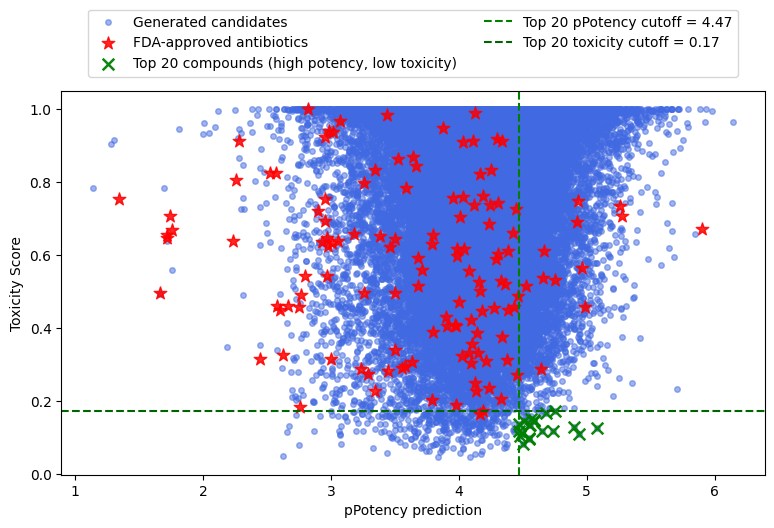

In [55]:
# Display cutoffs from the actual top 20 compounds
xDisplay = top20_2D_DF["pPotency_prediction"].min()
yDisplay = top20_2D_DF["coreToxicityScore"].max()

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    cand2DDF["pPotency_prediction"],
    cand2DDF["coreToxicityScore"],
    s=16, alpha=0.5, color="royalblue", label="Generated candidates"
)

ax.scatter(
    refScoreDF["pPotency_prediction"],
    refScoreDF["coreToxicityScore"],
    marker="*", s=90, alpha=0.85, color="red", label="FDA-approved antibiotics"
)

ax.scatter(
    top20_2D_DF["pPotency_prediction"],
    top20_2D_DF["coreToxicityScore"],
    marker="x", s=70, linewidths=1.8, alpha=0.95, color="green",
    label="Top 20 compounds (high potency, low toxicity)"
)

ax.axvline(
    xDisplay,
    linestyle="--",
    linewidth=1.5,
    color="green",
    label=f"Top 20 pPotency cutoff = {xDisplay:.2f}"
)

ax.axhline(
    yDisplay,
    linestyle="--",
    linewidth=1.5,
    color="darkgreen",
    label=f"Top 20 toxicity cutoff = {yDisplay:.2f}"
)

ax.set_xlabel("pPotency prediction")
ax.set_ylabel("Toxicity Score")

ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.90])

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_buyable.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_buyable.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### 15. Plot: `high pPotency`, `low Toxicity Score`, `high ADME feasibility`

Selection rule:
- pPotency in the top quartile
- Toxicity Score in the bottom quartile
- ADMEFeasibility in the top quartile

Within that region, ranking uses the unweighted geometric mean of:
- `PotencyDesRaw`
- `ToxicitySafety`
- `ADMEFeasibility`

In [56]:
cand3DDF = candScoreDF.copy()

cand3DDF = cand3DDF[
    cand3DDF[["pPotency_prediction", "coreToxicityScore", "ADMEFeasibility", "ToxicitySafety", "PotencyDesRaw"]]
    .notna()
    .all(axis=1)
].copy()

xCutoff3D = cand3DDF["pPotency_prediction"].quantile(0.75)
yCutoff3D = cand3DDF["coreToxicityScore"].quantile(0.25)
zCutoff3D = cand3DDF["ADMEFeasibility"].quantile(0.75)

optimal3DDF = cand3DDF[
    (cand3DDF["pPotency_prediction"] >= xCutoff3D) &
    (cand3DDF["coreToxicityScore"] <= yCutoff3D) &
    (cand3DDF["ADMEFeasibility"] >= zCutoff3D)
].copy()

optimal3DDF["OverallPriority3D"] = (
    optimal3DDF["PotencyDesRaw"] *
    optimal3DDF["ToxicitySafety"] *
    optimal3DDF["ADMEFeasibility"]
) ** (1 / 3)

top20_3D_DF = optimal3DDF.sort_values(
    by=["OverallPriority3D", "pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"],
    ascending=[False, False, True, False]
).head(20).copy()

top20_3D_DF["Top20Rank_3D"] = np.arange(1, len(top20_3D_DF) + 1)

top20_3D_DF[
    [
        "Top20Rank_3D",
        "smiles",
        "pPotency_prediction",
        "pPotency_std",
        "pPotency_lower_95CI",
        "coreToxicityScore",
        "ADMEFeasibility",
        "ToxicitySafety",
        "OverallPriority3D",
        "QED",
    ]
]

,Top20Rank_3D,smiles,pPotency_prediction,pPotency_std,pPotency_lower_95CI,coreToxicityScore,ADMEFeasibility,ToxicitySafety,OverallPriority3D,QED
8314,1,CNS(=O)(=O)c1cc(C(=O)NCc2nnc3n2CCC3)n(C)c1,4.550343,1.119746,2.355641,0.132172,0.846446,0.867828,0.876492,0.756244
31946,2,CCNC(=O)Cn1cnc2c1c(=O)[nH]c(=O)n2C,4.467259,1.118963,2.274091,0.136608,0.822509,0.863392,0.864275,0.697022
14322,3,Cc1cc(C(=O)O)ccc1S(=O)(=O)NCC1(C)CCC(=O)N1,4.601779,1.119041,2.408458,0.219509,0.791335,0.780491,0.827269,0.734832
27418,4,CCn1cnnc1CNC(=O)c1cc(S(N)(=O)=O)ccc1OC,4.473383,1.118918,2.280303,0.116490,0.697569,0.883510,0.824395,0.754839
10356,5,Cc1cc(C(=O)N2CCn3c(C)nnc3C2)cc(S(N)(=O)=O)c1C,4.486447,1.118452,2.294281,0.185218,0.730126,0.814782,0.814733,0.848821
11013,6,NCc1cc(C(=O)N2CCC(C(=O)O)CC2)[nH]n1,4.524980,1.119295,2.331162,0.167512,0.690488,0.832488,0.805466,0.689557
31251,7,CNS(=O)(=O)c1ccc(CN2CCCC2(C)C(=O)O)cc1,4.482377,1.120119,2.286944,0.159798,0.672573,0.840202,0.800897,0.847944
17528,8,Cn1ccc(C(=O)N2CCC(C)(NC(=O)CC3(C)CCS(=O)(=O)N3...,4.553625,1.119175,2.360042,0.279497,0.765539,0.720503,0.796657,0.777769
25891,9,CCn1cc(S(=O)(=O)NCc2ncnn2C(C)C)cn1,4.560789,1.119303,2.366956,0.230822,0.711710,0.769178,0.794659,0.840248
32508,10,Cn1c(=O)[nH]c(=O)c2c1nc(CN1CCOCC1)n2CC(N)=O,4.449348,1.118592,2.256907,0.300798,0.801957,0.699202,0.794366,0.653685


### 16. plot: pPotency vs Toxicity Score vs ADME feasibility

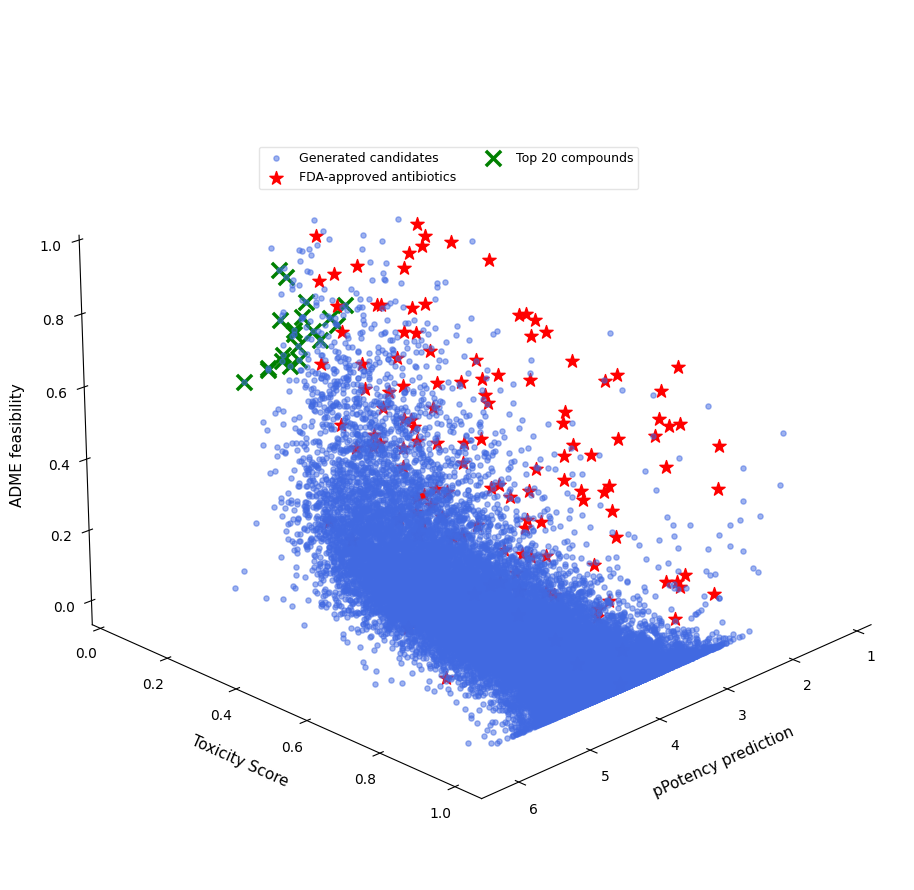

In [57]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(13, 10))
ax  = fig.add_subplot(111, projection="3d")

fig.patch.set_alpha(0.0)
ax.set_facecolor((0, 0, 0, 0))

for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
    pane.fill = False
    pane.set_edgecolor("lightgray")
    pane.set_alpha(0.0)

ax.grid(False)
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"]["linewidth"] = 0
    axis.label.set_color("k")
    axis.set_tick_params(colors="k")

ax.scatter(
    cand3DDF["pPotency_prediction"], cand3DDF["coreToxicityScore"], cand3DDF["ADMEFeasibility"],
    s=14, alpha=0.5, color="royalblue", label="Generated candidates", depthshade=False,
)
ax.scatter(
    refScoreDF["pPotency_prediction"], refScoreDF["coreToxicityScore"], refScoreDF["ADMEFeasibility"],
    marker="*", s=100, alpha=1.0, color="red", label="FDA-approved antibiotics", depthshade=False,
)
ax.scatter(
    top20_3D_DF["pPotency_prediction"], top20_3D_DF["coreToxicityScore"], top20_3D_DF["ADMEFeasibility"],
    marker="x", s=120, linewidths=2.5, alpha=1.0, color="green", label="Top 20 compounds", depthshade=False,
)

xCutoff = top20_3D_DF["pPotency_prediction"].min()
yCutoff = top20_3D_DF["coreToxicityScore"].max()
zCutoff = top20_3D_DF["ADMEFeasibility"].min()

xMin, xMax = ax.get_xlim()
yMin, yMax = ax.get_ylim()
zMin, zMax = ax.get_zlim()

#cutoffStyle = dict(linewidth=1.8, linestyle="--", alpha=0.85)
#ax.plot([xMin,    xCutoff], [yCutoff, yCutoff], [zCutoff, zCutoff], color="green",     label=f"pPotency cutoff = {xCutoff:.2f}", **cutoffStyle)
#ax.plot([xCutoff, xCutoff], [yCutoff, yMax],    [zCutoff, zCutoff], color="darkolivegreen", label=f"Toxicity cutoff = {yCutoff:.2f}", **cutoffStyle)
#ax.plot([xCutoff, xCutoff], [yCutoff, yCutoff], [zMin,    zCutoff], color="seagreen",  label=f"ADME cutoff = {zCutoff:.2f}",    **cutoffStyle)
#ax.scatter([xCutoff], [yCutoff], [zCutoff], marker="D", s=180, color="gold", edgecolors="darkorange", linewidths=1.5, zorder=10, label="Optimal cutoff corner", depthshade=False)

ax.set_xlabel("pPotency prediction", labelpad=10, color="k", fontsize=11)
ax.set_ylabel("Toxicity Score", labelpad=10, color="k", fontsize=11)
ax.set_zlabel("ADME feasibility",    labelpad=10, color="k", fontsize=11)
ax.set_zlabel("")
ax.text2D(-0.02, 0.5, "ADME feasibility", transform=ax.transAxes, fontsize=11, color="k", rotation=90, va="center", ha="center")

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.set_tick_params(colors="k", labelsize=10)

ax.view_init(elev=22, azim=45)
ax.legend(loc="upper left", bbox_to_anchor=(0.25, 0.85), ncol=2, frameon=True, framealpha=0.3, facecolor="white", edgecolor="darkgray", labelcolor="black", fontsize=9)
fig.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.05)

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_3d_buyable.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_3d_buyable.png")
plt.savefig(svg_path, format="svg", dpi=600, transparent=True, pad_inches=0.5)
plt.savefig(png_path, format="png", dpi=600, transparent=True, pad_inches=0.5)
plt.show()

### 17. Custom projected 3D plot for presentation

This is a presentation-oriented 2D projection of 3 variables.

Projected axes:
- horizontal right = `pPotency`
- vertical up = `Toxicity Score`
- diagonal lower-left = `ADME feasibility`

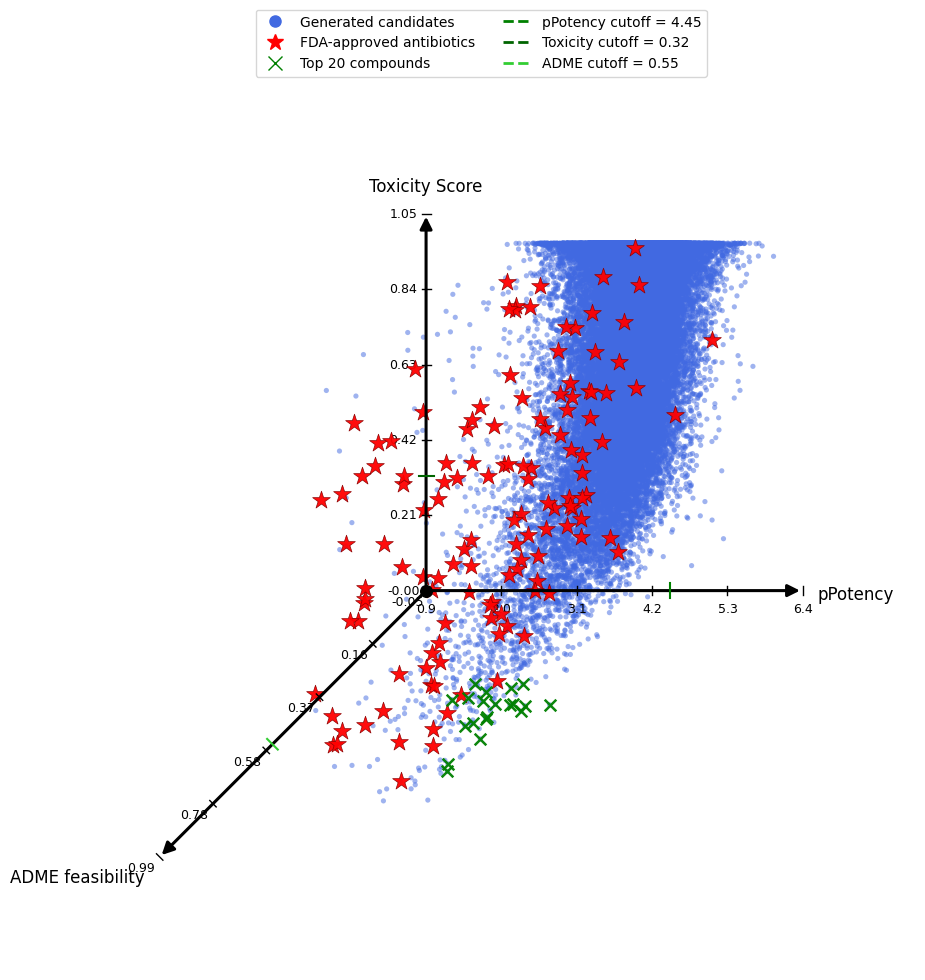

In [68]:
xCol, yCol, zCol = "pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"
cols = [xCol, yCol, zCol]

allPlotDF = cand3DDF[cols][np.isfinite(cand3DDF[cols]).all(axis=1)].copy()
refPlotDF = refScoreDF[cols][np.isfinite(refScoreDF[cols]).all(axis=1)].copy()
topPlotDF = top20_3D_DF[cols][np.isfinite(top20_3D_DF[cols]).all(axis=1)].copy()

def paddedRange(arr, frac=0.05):
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    pad = (hi - lo) * frac if (hi - lo) > 0 else 1.0
    return lo - pad, hi + pad

combined          = pd.concat([allPlotDF, refPlotDF, topPlotDF])
(X_MIN, X_MAX), (Y_MIN, Y_MAX), (Z_MIN, Z_MAX) = [paddedRange(combined[c]) for c in cols]

O  = np.zeros(2)
UX = np.array([1.0, 0.0])
UY = np.array([0.0, 1.0])
UZ = np.array([math.cos(math.radians(225)), math.sin(math.radians(225))])

def project(x, y, z):
    return O + ((x-X_MIN)/(X_MAX-X_MIN))*UX + ((y-Y_MIN)/(Y_MAX-Y_MIN))*UY + ((z-Z_MIN)/(Z_MAX-Z_MIN))*UZ

def projectDF(df):
    pts = np.array([project(r[xCol], r[yCol], r[zCol]) for _, r in df.iterrows()])
    return pts[:, 0], pts[:, 1]

allCX, allCY = projectDF(allPlotDF)
refCX, refCY = projectDF(refPlotDF)
topCX, topCY = projectDF(topPlotDF)

TIP_X, TIP_Y, TIP_Z = O + UX, O + UY, O + UZ

fig, ax = plt.subplots(figsize=(12, 11), facecolor="white")
ax.set(facecolor="white", aspect="equal")
ax.axis("off")

for tip in [TIP_X, TIP_Y, TIP_Z]:
    ax.annotate("", xy=tip, xytext=O, zorder=5,
                arrowprops=dict(arrowstyle="-|>", color="black", lw=2.2, mutation_scale=18))

ax.scatter(*O, s=70, c="black", zorder=6)

def drawTicks(unitVec, valMin, valMax, offset, nTicks=5, fmt="{:.2f}"):
    perp = np.array([unitVec[1], -unitVec[0]])
    perp /= np.linalg.norm(perp)
    for i in range(nTicks + 1):
        t, pos = i / nTicks, O + (i / nTicks) * unitVec
        ax.plot(*zip(pos - 0.012*perp, pos + 0.012*perp), color="black", lw=1.0, zorder=5)
        ax.text(*(pos + offset), fmt.format(valMin + t*(valMax-valMin)), fontsize=9, ha="center", va="center")

drawTicks(UX, X_MIN, X_MAX, np.array([ 0.00, -0.05]), fmt="{:.1f}")
drawTicks(UY, Y_MIN, Y_MAX, np.array([-0.06,  0.00]))
drawTicks(UZ, Z_MIN, Z_MAX, np.array([-0.05, -0.03]))

ax.scatter(allCX, allCY, color="royalblue", s=14,  alpha=0.5,  edgecolors="none", zorder=2)
ax.scatter(refCX, refCY, color="red",       s=180, alpha=0.95, marker="*", edgecolors="darkred", linewidths=0.5, zorder=4)
ax.scatter(topCX, topCY, color="green",     s=70,  alpha=0.95, marker="x", linewidths=1.8, zorder=5)

xCut, yCut, zCut = topPlotDF[xCol].min(), topPlotDF[yCol].max(), topPlotDF[zCol].min()
tickLen = 0.02

UZ_perp = np.array([-UZ[1], UZ[0]]) 
UZ_perp /= np.linalg.norm(UZ_perp)           
zPt = O + ((zCut-Z_MIN)/(Z_MAX-Z_MIN))*UZ 

for pt, color, dx, dy in [
    (O + ((xCut-X_MIN)/(X_MAX-X_MIN))*UX, "green", 0, tickLen),
    (O + ((yCut-Y_MIN)/(Y_MAX-Y_MIN))*UY, "darkgreen",  tickLen, 0),
]:
    ax.plot([pt[0]-dx, pt[0]+dx], [pt[1]-dy, pt[1]+dy], color=color, lw=1.5, zorder=5)

# Z cutoff tick perpendicular to UZ
ax.plot(
    [zPt[0] - tickLen*UZ_perp[0], zPt[0] + tickLen*UZ_perp[0]],
    [zPt[1] - tickLen*UZ_perp[1], zPt[1] + tickLen*UZ_perp[1]],
    color="limegreen", lw=1.5, zorder=5
)

ax.text(TIP_X[0]+0.04, TIP_X[1]-0.01, "pPotency",            fontsize=12, ha="left",   va="center")
ax.text(TIP_Y[0],      TIP_Y[1]+0.05, "Toxicity Score",  fontsize=12, ha="center", va="bottom")
ax.text(TIP_Z[0]-0.04, TIP_Z[1]-0.03, "ADME feasibility",    fontsize=12, ha="right",  va="top")

allPx = np.concatenate([allCX, refCX, topCX, [TIP_X[0], TIP_Y[0], TIP_Z[0]]])
allPy = np.concatenate([allCY, refCY, topCY, [TIP_X[1], TIP_Y[1], TIP_Z[1]]])
ax.set_xlim(allPx.min()-0.3, allPx.max()+0.3)
ax.set_ylim(allPy.min()-0.3, allPy.max()+0.3)

handles = [
    mlines.Line2D([], [], color="royalblue", marker="o", linestyle="None", markersize=8, label="Generated candidates"),
    mlines.Line2D([], [], color="red",       marker="*", linestyle="None", markersize=12, label="FDA-approved antibiotics"),
    mlines.Line2D([], [], color="green",     marker="x", linestyle="None", markersize=10, label="Top 20 compounds"),
    mlines.Line2D([], [], color="green",     linestyle="--", lw=2, label=f"pPotency cutoff = {xCut:.2f}"),
    mlines.Line2D([], [], color="darkgreen", linestyle="--", lw=2, label=f"Toxicity cutoff = {yCut:.2f}"),
    mlines.Line2D([], [], color="limegreen", linestyle="--", lw=2, label=f"ADME cutoff = {zCut:.2f}"),
]
ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_buyable.svg"), format="svg", dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_buyable.png"), format="png", dpi=600, bbox_inches="tight", facecolor="white")
plt.show()

### 18. Save the top 20 candidates

In [59]:
top20_2D_cols = ["Top20Rank_2D", "smiles", "pPotency_prediction", "pPotency_std", "pPotency_lower_95CI", "pPotency_upper_95CI", "coreToxicityScore", "ToxicitySafety", "OverallPriority2D", "QED"]
top20_3D_cols = ["Top20Rank_3D", "smiles", "pPotency_prediction", "pPotency_std", "pPotency_lower_95CI", "pPotency_upper_95CI", "coreToxicityScore", "ADMEFeasibility", "ToxicitySafety", "OverallPriority3D", "QED"]

toxicityTop20Path = os.path.join(saveDir, f"{target_organism}_potency_coreToxicity_top20_buyable.csv")
admetTop20Path    = os.path.join(saveDir, f"{target_organism}_potency_coreToxicity_adme_top20_buyable.csv")

top20_2D_DF[top20_2D_cols[1:]].to_csv(toxicityTop20Path, index=False)
top20_3D_DF[top20_3D_cols[1:]].to_csv(admetTop20Path,    index=False)

print(f"Saved:\n- {toxicityTop20Path}\n- {admetTop20Path}")

#display(top20_2D_DF[top20_2D_cols])
#display(top20_3D_DF[top20_3D_cols])

Saved:
- /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB/BacillusAnthracis_potency_coreToxicity_top20_buyable.csv
- /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB/BacillusAnthracis_potency_coreToxicity_adme_top20_buyable.csv


# Check ADMET properties for `DOranet + DORA-XGB` generated antibiotics

### 1. Read `ART` predicted `pPotency` of all the compounds

In [72]:
BacillusAnthracis_wART_BasidalinPrecursor_predicted_all = pd.read_csv(saveDir + f'{target_organism}_BasidalinPrecursorDORAnetGenerated_Antibiotic_ARTprediction.csv')
max_val = BacillusAnthracis_wART_BasidalinPrecursor_predicted_all['pPotency_prediction'].max()
min_val = BacillusAnthracis_wART_BasidalinPrecursor_predicted_all['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
BacillusAnthracis_wART_BasidalinPrecursor_predicted_all

pPotency_prediction range: 1.800 → 5.331


,SMILES,Is_Starter,SourceDirectories,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,basidalin_Precursor,5.331199,1.119903,3.136188,7.526210,0.000005,2.977075e-08,0.000731
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,basidalin_Precursor,3.626339,1.118850,1.433394,5.819284,0.000236,1.516058e-06,0.036864
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,basidalin_Precursor,4.428906,1.118935,2.235793,6.622019,0.000037,2.387706e-07,0.005810
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,basidalin_Precursor,4.461134,1.118921,2.268049,6.654220,0.000035,2.217075e-07,0.005394
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,basidalin_Precursor,4.480122,1.118720,2.287430,6.672814,0.000033,2.124154e-07,0.005159
...,...,...,...,...,...,...,...,...,...,...
651805,C[C@H](N)CC1=C(O)C(=O)OC1=C[C@@H](C)CNC=O,False,basidalin_Precursor,3.338849,1.119381,1.144863,5.532836,0.000458,2.931999e-06,0.071637
651806,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,False,basidalin_Precursor,3.427273,1.119665,1.232729,5.621817,0.000374,2.388817e-06,0.058515
651807,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,False,basidalin_Precursor,3.531349,1.118973,1.338161,5.724536,0.000294,1.885662e-06,0.045903
651808,CC1=C2O[C@](C)(N)C(O)NC[C@H](C)C=C1OC2=O,False,basidalin_Precursor,3.828076,1.119069,1.634701,6.021451,0.000149,9.518076e-07,0.023190


### Retain only the molecules produced through high-feasibility reactions, as validated by the DPRA-XGB classifier.

In [75]:
doraxgbDir='/users/sghosh6/DTRA_project/MACAW/doranet/scripts/RetroTide_basidalinPrecursor'
BasidalinPrecursor_highFeasibility_molecules = pd.read_csv(doraxgbDir + '/allReactants_gen2/basidalinPrecursor_gen2_uniqueMolecules.csv')
BasidalinPrecursor_highFeasibility_molecules

,SMILES,Is_reactant,Is_product,Is_Starter,SourceDirectory
0,O=C1OC(=C[C@@H]2CCC[C@H]2C(=O)O)[C@@H](O)[C@@H]1O,True,False,True,basidalinPrecursor_gen2
1,C=CC[C@H]1CC(=CCCC)OC1=O,True,True,True,basidalinPrecursor_gen2
2,CC[C@H](C=C1OC(=O)[C@@H](C)C1=O)C(N)=O,True,True,True,basidalinPrecursor_gen2
3,CCC1=CC(=Cc2ccc([N+](=O)[O-])cc2)OC1=O,True,False,True,basidalinPrecursor_gen2
4,CC=C1OC(=O)[C@@H](CCCCCC)[C@@H]1O,True,True,True,basidalinPrecursor_gen2
...,...,...,...,...,...
173854,O=C(O)[C@@H](O)CC(O)=CCCCCO,False,True,False,basidalinPrecursor_gen2
173855,CC(C)C=C1OC(=O)[C@H](CCCCO)[C@@H]1O,True,True,False,basidalinPrecursor_gen2
173856,CO[C@H]1CC(=O)OC1=C(C)O,False,True,False,basidalinPrecursor_gen2
173857,CCCC1=CC(=CCC(N)=O)OC1=O,True,True,False,basidalinPrecursor_gen2


In [76]:
def canonicalize(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        return Chem.MolToSmiles(mol) if mol else None
    except:
        return None

# Canonicalize SMILES in both DataFrames
BacillusAnthracis_wART_BasidalinPrecursor_predicted_all["canon_SMILES"] = \
    BacillusAnthracis_wART_BasidalinPrecursor_predicted_all["SMILES"].apply(canonicalize)

BasidalinPrecursor_highFeasibility_molecules["canon_SMILES"] = \
    BasidalinPrecursor_highFeasibility_molecules["SMILES"].apply(canonicalize)

# Get valid canonical SMILES set from highFeasibility
highFeasibility_set = set(BasidalinPrecursor_highFeasibility_molecules["canon_SMILES"].dropna())

# Filter: keep only SMILES present in highFeasibility
BacillusAnthracis_wART_BasidalinPrecursor_predicted_all = \
    BacillusAnthracis_wART_BasidalinPrecursor_predicted_all[
        BacillusAnthracis_wART_BasidalinPrecursor_predicted_all["canon_SMILES"].isin(highFeasibility_set)
    ].drop(columns="canon_SMILES").reset_index(drop=True)

print(f"Filtered shape: {BacillusAnthracis_wART_BasidalinPrecursor_predicted_all.shape}")

Filtered shape: (173858, 10)


### plot `pPotency` distribution with error bars

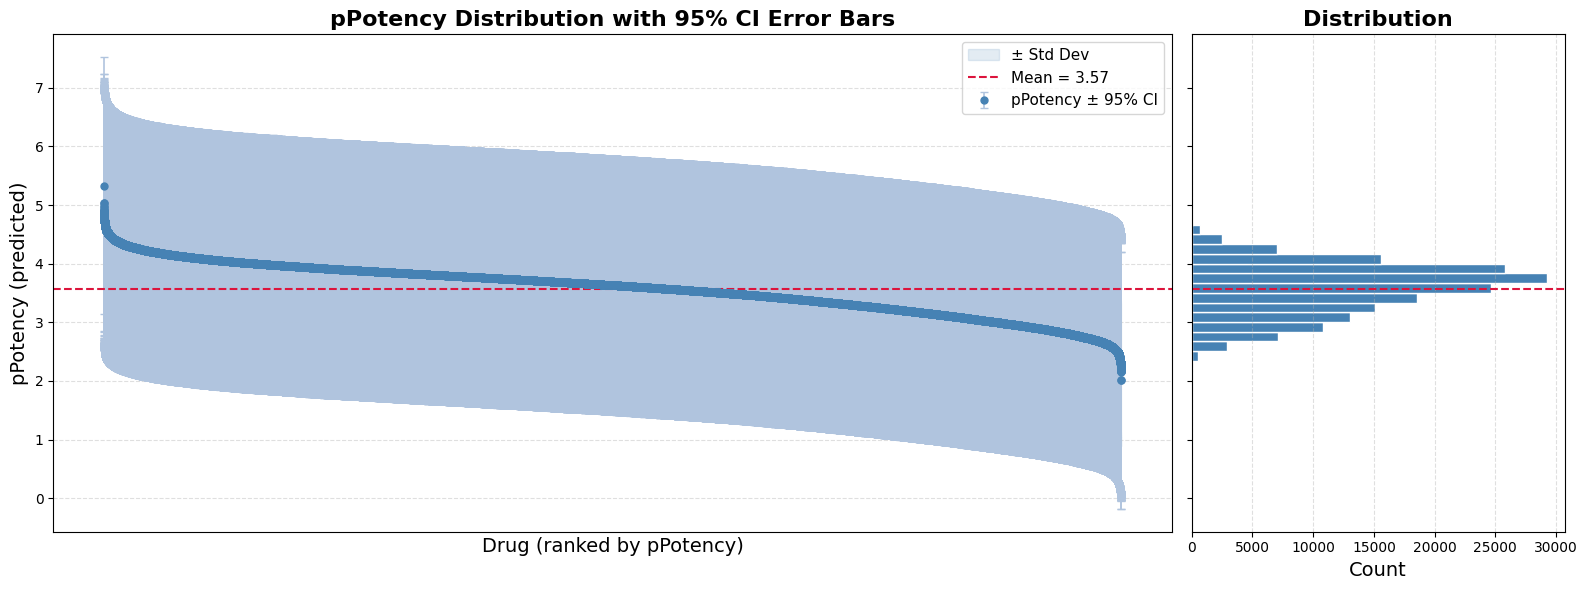

In [77]:
ppotencyDF = BacillusAnthracis_wART_BasidalinPrecursor_predicted_all.sort_values(
    "pPotency_prediction", ascending=False).reset_index(drop=True)

x = np.arange(len(ppotencyDF))
pred = ppotencyDF["pPotency_prediction"]
yerr = np.array([pred - ppotencyDF["pPotency_lower_95CI"],
                 ppotencyDF["pPotency_upper_95CI"] - pred])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6),
                                gridspec_kw={"width_ratios": [3, 1]}, sharey=True)

# ── Scatter + error bars ──────────────────────────────────────────────────────
ax1.errorbar(x, pred, yerr=yerr, fmt='o', color='steelblue', ecolor='lightsteelblue',
             elinewidth=1.2, capsize=3, markersize=5, alpha=1, label="pPotency ± 95% CI")
ax1.fill_between(x, pred - ppotencyDF["pPotency_std"], pred + ppotencyDF["pPotency_std"],
                 alpha=0.15, color='steelblue', label="± Std Dev")
ax1.axhline(pred.mean(),   color='crimson',    linestyle='--', linewidth=1.5, label=f'Mean = {pred.mean():.2f}')
#ax1.axhline(pred.median(), color='darkorange', linestyle=':',  linewidth=1.5, label=f'Median = {pred.median():.2f}')
ax1.set_xlabel("Drug (ranked by pPotency)", fontsize=14)  
ax1.set_ylabel("pPotency (predicted)",      fontsize=14) 
ax1.set_title("pPotency Distribution with 95% CI Error Bars", fontsize=16, fontweight='bold')  
ax1.set_xticks([])
ax1.legend(fontsize=11); ax1.grid(axis='y', linestyle='--', alpha=0.4)

# ── Histogram ─────────────────────────────────────────────────────────────────
ax2.hist(pred, bins=20, orientation='horizontal', color='steelblue', edgecolor='white', alpha=1)
ax2.axhline(pred.mean(),   color='crimson',    linestyle='--', linewidth=1.5)
#ax2.axhline(pred.median(), color='darkorange', linestyle=':',  linewidth=1.5)
ax2.set_xlabel("Count", fontsize=14)        
ax2.set_title("Distribution", fontsize=16, fontweight='bold') 
ax2.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_distribution_BasidalinPrecursor.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_distribution_BasidalinPrecursor.png")
plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### Read predicted `ADMET` properties for all candidate SMILES

In [78]:
BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity = pd.read_csv(saveDir + f'{target_organism}_BasidalinPrecursorDORAnetGenerated_Antibiotic_ARTprediction_wToxicity.csv')
# Identify columns that match the string
matched_cols = BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity.filter(like='drugbank_approved_percentile').columns
# Keep everything EXCEPT those columns
BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity = BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity.drop(columns=matched_cols)
max_val = BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity['pPotency_prediction'].max()
min_val = BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity

pPotency_prediction range: 1.800 → 5.331


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang,Clearance_Hepatocyte_AZ,Clearance_Microsome_AZ,Half_Life_Obach,HydrationFreeEnergy_FreeSolv,LD50_Zhu,Lipophilicity_AstraZeneca,PPBR_AZ,Solubility_AqSolDB,VDss_Lombardo
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.331199,1.119903,3.136188,7.526210,0.000005,2.977075e-08,0.000731,507.182,-1.62900,...,-6.532908,10.607536,21.695647,50.300162,-17.205968,1.654107,0.655960,57.025779,-0.437743,-4.687410
1,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,4.428906,1.118935,2.235793,6.622019,0.000037,2.387706e-07,0.005810,785.557,-2.42396,...,-6.475772,-3.364867,23.998967,23.188328,-17.767413,2.572223,0.824762,72.098404,-1.021829,-8.492948
2,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,4.461134,1.118921,2.268049,6.654220,0.000035,2.217075e-07,0.005394,787.573,-1.75026,...,-6.679487,1.394358,30.020669,41.759685,-18.648854,2.694055,1.037456,70.919499,-0.882326,-5.521714
3,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,4.529551,1.118626,2.337043,6.722059,0.000030,1.896448e-07,0.004602,744.417,-2.89890,...,-6.818474,5.750305,18.362396,75.728975,-19.110544,1.835266,0.205004,52.787176,0.022007,-3.040320
4,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,4.886733,1.119159,2.693181,7.080285,0.000013,8.312178e-08,0.002027,745.425,-2.56940,...,-6.744336,16.908523,47.892034,53.422075,-18.034575,2.189310,0.593944,55.243972,-0.186449,-8.067867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210076,CC(=O)N(C[C@H](C)C=C1C=C(O)C(=O)O1)C(=O)CN,3.235006,1.120611,1.038608,5.431404,0.000582,3.703361e-06,0.091494,268.269,-0.16110,...,-4.942543,19.222275,-13.245729,-26.206140,-13.784199,2.038853,-0.782325,56.416938,-1.252166,4.609630
210077,C=C1OC(=O)C(O)=C1C[C@@H](C)CNC(=O)[C@H](C)N,4.017921,1.118431,1.825797,6.210045,0.000096,6.165312e-07,0.014935,254.286,0.35860,...,-4.971337,18.877715,-7.608197,-16.089244,-12.828560,2.241299,-0.052081,47.861599,-0.621900,0.049090
210078,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,3.427273,1.119665,1.232729,5.621817,0.000374,2.388817e-06,0.058515,236.271,-0.15188,...,-4.665920,26.431825,-3.949410,4.130865,-13.637193,2.929543,0.018285,67.610269,-1.883527,4.866808
210079,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,3.531349,1.118973,1.338161,5.724536,0.000294,1.885662e-06,0.045903,254.286,-0.39730,...,-5.117675,22.680652,-22.316851,-11.262022,-13.711330,2.263901,-0.539212,33.198010,-0.924615,-1.704941


In [79]:
def canonicalize(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        return Chem.MolToSmiles(mol) if mol else None
    except:
        return None

# Canonicalize SMILES in both DataFrames
BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity["canon_SMILES"] = \
    BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity["SMILES"].apply(canonicalize)

BasidalinPrecursor_highFeasibility_molecules["canon_SMILES"] = \
    BasidalinPrecursor_highFeasibility_molecules["SMILES"].apply(canonicalize)

# Get valid canonical SMILES set from highFeasibility
highFeasibility_set = set(BasidalinPrecursor_highFeasibility_molecules["canon_SMILES"].dropna())

# Filter: keep only SMILES present in highFeasibility
BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity = \
    BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity[
        BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity["canon_SMILES"].isin(highFeasibility_set)
    ].drop(columns="canon_SMILES").reset_index(drop=True)

print(f"Filtered shape: {BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity.shape}")

Filtered shape: (58966, 57)


### 2. Antibiotic candidate prioritization by comparing with `Drugbank`

In [80]:
refDrugbankDF = drugBankDrug_FDAapproved_antibiotic_wART_wADMET.copy()
generatedCandidateDF = BacillusAnthracis_wART_BasidalinPrecursorDataset_predicted_all_wToxicity.copy()

print("Drugbank reference dataframe shape:", refDrugbankDF.shape)
print("Generated candidate dataframe shape:", generatedCandidateDF.shape)

Drugbank reference dataframe shape: (132, 44)
Generated candidate dataframe shape: (58966, 57)


### 3. Harmonize metadata and the SMILES column

The candidate dataframe may use `SMILES` instead of `smiles`.  
This cell standardizes that and fills a few metadata fields if they are missing.

In [81]:
if "SMILES" in generatedCandidateDF.columns:
    generatedCandidateDF = generatedCandidateDF.rename(columns={"SMILES": "smiles"})

if "ATC_code" not in generatedCandidateDF.columns:
    generatedCandidateDF["ATC_code"] = pd.NA

if "Drug_Type" not in generatedCandidateDF.columns:
    generatedCandidateDF["Drug_Type"] = "Predicted_candidate"

if "source_DataBase" not in generatedCandidateDF.columns:
    generatedCandidateDF["source_DataBase"] = "Generated"

refDrugbankDF["datasetLabel"] = "FDA-approved antibiotics"
generatedCandidateDF["datasetLabel"] = "Generated candidates"

print("smiles in refDrugbankDF:", "smiles" in refDrugbankDF.columns)
print("smiles in generatedCandidateDF:", "smiles" in generatedCandidateDF.columns)

smiles in refDrugbankDF: True
smiles in generatedCandidateDF: True


### 4. Define `ADMET` column groups

We keep:
- metadata
- potency-related columns
- toxicity-related columns
- ADME-related columns
- a few physicochemical property columns such as `QED`, `logP` and `molecular_weight`

In [82]:
metadataCols = [
    "smiles",
    "ATC_code",
    "Drug_Type",
    "source_DataBase",
    "datasetLabel",
]

potencyCols = [
    "pPotency_prediction",
    "pPotency_std",
    "pPotency_lower_95CI",
    "pPotency_upper_95CI",
    "IC50(M)_prediction",
    "IC50(M)_lower_95CI",
    "IC50(M)_upper_95CI",
]

toxicityCols = [
    "AMES",
    "Carcinogens_Lagunin",
    "ClinTox",
    "DILI",
    "Skin_Reaction",
    "hERG",
    "LD50_Zhu",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma",
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
]

admeCols = [
    "Bioavailability_Ma",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Caco2_Wang",
    "Solubility_AqSolDB",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith",
    "Pgp_Broccatelli",
    "Clearance_Hepatocyte_AZ",
    "Clearance_Microsome_AZ",
    "Half_Life_Obach",
    "PPBR_AZ",
    "VDss_Lombardo",
]

optionalCols = ["BBB_Martins"]

physicochemCols = [
    "molecular_weight",
    "logP",
    "hydrogen_bond_acceptors",
    "hydrogen_bond_donors",
    "Lipinski",
    "QED",
    "stereo_centers",
    "tpsa",
    "HydrationFreeEnergy_FreeSolv",
    "Lipophilicity_AstraZeneca",
]

keepCols = list(dict.fromkeys(metadataCols + potencyCols + toxicityCols + admeCols + optionalCols + physicochemCols))
print("Total kept columns:", len(keepCols))

Total kept columns: 61


### 5. Build aligned reference and candidate dataframes

This cell keeps the same columns in both dataframes and creates any missing columns as `NaN`

In [83]:
def ensureCols(DF, colList):
    outDF = DF.copy()
    for colName in colList:
        if colName not in outDF.columns:
            outDF[colName] = np.nan
    return outDF[colList].copy()

refScoreDF = ensureCols(refDrugbankDF, keepCols)
candScoreDF = ensureCols(generatedCandidateDF, keepCols)

print("Reference aligned shape:", refScoreDF.shape)
print("Candidate aligned shape:", candScoreDF.shape)

Reference aligned shape: (132, 61)
Candidate aligned shape: (58966, 61)


### 6. Convert relevant columns to numeric

All scoring-related columns are converted to numeric.  

In [84]:
numericCols = list(dict.fromkeys(potencyCols + toxicityCols + admeCols + optionalCols + physicochemCols))

for colName in numericCols:
    if colName in refScoreDF.columns:
        refScoreDF[colName] = pd.to_numeric(refScoreDF[colName], errors="coerce")
    if colName in candScoreDF.columns:
        candScoreDF[colName] = pd.to_numeric(candScoreDF[colName], errors="coerce")

refScoreDF["potencyConservative"] = refScoreDF["pPotency_lower_95CI"].fillna(refScoreDF["pPotency_prediction"])
candScoreDF["potencyConservative"] = candScoreDF["pPotency_lower_95CI"].fillna(candScoreDF["pPotency_prediction"])

### 7. Define endpoint metadata

This table contains:
- endpoint name
- whether it belongs to the **toxicity** or **adme** group
- the direction of desirability:
  - `lowerBetter`
  - `higherBetter`
  - `referenceMatch`


In [85]:
endpointMetaDF = pd.DataFrame([
    # Toxicity
    {"endpoint": "AMES",                "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "Carcinogens_Lagunin", "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "ClinTox",             "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "DILI",                "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "Skin_Reaction",       "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "hERG",                "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "LD50_Zhu",            "majorGroup": "toxicity", "direction": "higherBetter"},
    {"endpoint": "NR-AR-LBD",           "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-AR",               "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-AhR",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-Aromatase",        "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-ER-LBD",           "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-ER",               "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-PPAR-gamma",       "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-ARE",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-ATAD5",            "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-HSE",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-MMP",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-p53",              "majorGroup": "toxicity", "direction": "lowerBetter"},

    # ADME
    {"endpoint": "Bioavailability_Ma",             "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "HIA_Hou",                        "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "PAMPA_NCATS",                    "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "Caco2_Wang",                     "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "Solubility_AqSolDB",             "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "CYP1A2_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP2C19_Veith",                  "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP2C9_Substrate_CarbonMangels", "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "CYP2C9_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP2D6_Substrate_CarbonMangels", "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "CYP2D6_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP3A4_Substrate_CarbonMangels", "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "CYP3A4_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "Pgp_Broccatelli",                "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "Clearance_Hepatocyte_AZ",        "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "Clearance_Microsome_AZ",         "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "Half_Life_Obach",                "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "PPBR_AZ",                        "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "VDss_Lombardo",                  "majorGroup": "adme", "direction": "referenceMatch"},
])

endpointMetaDF

,endpoint,majorGroup,direction
0,AMES,toxicity,lowerBetter
1,Carcinogens_Lagunin,toxicity,lowerBetter
2,ClinTox,toxicity,lowerBetter
3,DILI,toxicity,lowerBetter
4,Skin_Reaction,toxicity,lowerBetter
5,hERG,toxicity,lowerBetter
6,LD50_Zhu,toxicity,higherBetter
7,NR-AR-LBD,toxicity,lowerBetter
8,NR-AR,toxicity,lowerBetter
9,NR-AhR,toxicity,lowerBetter


### 8. Derive fully statistical endpoint weights from FDA-approved antibiotics from `Drugbank`

For each endpoint we compute:

- **informativeness** = inverse of the reference IQR  
  A tighter approved-antibiotic distribution means the endpoint is more constrained and therefore more informative.

- **uniqueness** = inverse redundancy penalty  
  Endpoints that are highly correlated with other endpoints in the same group get reduced weight.

The final endpoint weights are normalized inside each major group:
- `toxicity`
- `adme`

In [86]:
def robustIQR(series):
    cleanSeries = pd.to_numeric(series, errors="coerce").dropna()
    if len(cleanSeries) < 5:
        return np.nan
    q25, q75 = np.percentile(cleanSeries, [25, 75])
    return q75 - q25

weightRows = []

for majorGroupName in endpointMetaDF["majorGroup"].unique():
    groupMetaDF = endpointMetaDF[endpointMetaDF["majorGroup"] == majorGroupName].copy()
    groupEndpoints = groupMetaDF["endpoint"].tolist()

    groupRefDF = refScoreDF[groupEndpoints].apply(pd.to_numeric, errors="coerce")
    groupCorrDF = groupRefDF.corr().abs()

    for endpointName in groupEndpoints:
        series = groupRefDF[endpointName]
        iqrValue = robustIQR(series)

        informativeness = 1.0 / (iqrValue + 1e-6) if pd.notna(iqrValue) else 1.0

        otherEndpoints = [x for x in groupEndpoints if x != endpointName]
        if len(otherEndpoints) > 0 and endpointName in groupCorrDF.index:
            meanAbsCorr = groupCorrDF.loc[endpointName, otherEndpoints].dropna().mean()
            uniqueness = max(1.0 - meanAbsCorr, 1e-3) if pd.notna(meanAbsCorr) else 1.0
        else:
            uniqueness = 1.0

        rawWeight = informativeness * uniqueness

        weightRows.append({
            "endpoint": endpointName,
            "majorGroup": majorGroupName,
            "direction": groupMetaDF.loc[groupMetaDF["endpoint"] == endpointName, "direction"].iloc[0],
            "iqrValue": iqrValue,
            "informativeness": informativeness,
            "uniqueness": uniqueness,
            "rawWeight": rawWeight,
        })

weightDF = pd.DataFrame(weightRows)
weightDF["finalWeight"] = (
    weightDF.groupby("majorGroup")["rawWeight"]
    .transform(lambda x: x / x.sum())
)

weightDF.sort_values(["majorGroup", "finalWeight"], ascending=[True, False])

,endpoint,majorGroup,direction,iqrValue,informativeness,uniqueness,rawWeight,finalWeight
24,CYP1A2_Veith,adme,lowerBetter,0.007583,131.856666,0.875912,115.494897,0.374049
27,CYP2C9_Veith,adme,lowerBetter,0.015054,66.424005,0.743478,49.384762,0.159941
29,CYP2D6_Veith,adme,lowerBetter,0.023108,43.273037,0.852122,36.873917,0.119422
25,CYP2C19_Veith,adme,lowerBetter,0.020200,49.501684,0.716789,35.482260,0.114915
28,CYP2D6_Substrate_CarbonMangels,adme,referenceMatch,0.027401,36.494317,0.742754,27.106292,0.087788
31,CYP3A4_Veith,adme,lowerBetter,0.048597,20.577056,0.715226,14.717253,0.047664
32,Pgp_Broccatelli,adme,referenceMatch,0.087841,11.384115,0.775158,8.824486,0.028580
26,CYP2C9_Substrate_CarbonMangels,adme,referenceMatch,0.105874,9.445118,0.747599,7.061157,0.022869
30,CYP3A4_Substrate_CarbonMangels,adme,referenceMatch,0.278713,3.587905,0.749184,2.688000,0.008706
21,PAMPA_NCATS,adme,higherBetter,0.311315,3.212166,0.586158,1.882835,0.006098


### 9. Helper functions for desirability scoring and weighted aggregation

This section defines:

- percentile-based desirability functions
- a reference-matching desirability function
- weighted geometric mean aggregation

In [87]:
def getSortedRefArray(refSeries):
    refArray = pd.to_numeric(refSeries, errors="coerce").dropna().to_numpy(dtype=float)
    refArray = refArray[np.isfinite(refArray)]
    refArray = np.sort(refArray)
    return refArray

def higherBetterDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan, dtype=float)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    finiteMask = np.isfinite(valueArray)
    percentArray = np.searchsorted(refArray, valueArray[finiteMask], side="right") / len(refArray)
    outArray[finiteMask] = np.clip(percentArray, 0.0, 1.0)
    return pd.Series(outArray, index=valueSeries.index)

def lowerBetterDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan, dtype=float)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    finiteMask = np.isfinite(valueArray)
    percentArray = np.searchsorted(refArray, valueArray[finiteMask], side="right") / len(refArray)
    outArray[finiteMask] = np.clip(1.0 - percentArray, 0.0, 1.0)
    return pd.Series(outArray, index=valueSeries.index)

def referenceMatchDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan, dtype=float)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    refMedian = np.nanmedian(refArray)
    q25, q75 = np.nanpercentile(refArray, [25, 75])
    robustSigma = (q75 - q25) / 1.349 if q75 > q25 else np.nanstd(refArray)

    if not np.isfinite(robustSigma) or robustSigma <= 0:
        robustSigma = 1e-6

    finiteMask = np.isfinite(valueArray)
    zArray = (valueArray[finiteMask] - refMedian) / robustSigma
    outArray[finiteMask] = np.exp(-0.5 * (zArray ** 2))
    outArray = np.clip(outArray, 0.0, 1.0)

    return pd.Series(outArray, index=valueSeries.index)

def weightedGeoMeanSeries(DF, valueColList, weightSeries):
    valueMatrix = DF[valueColList].to_numpy(dtype=float)
    weightArray = np.asarray(weightSeries, dtype=float)
    outArray = np.full(valueMatrix.shape[0], np.nan, dtype=float)

    for rowIdx in range(valueMatrix.shape[0]):
        rowArray = valueMatrix[rowIdx]
        finiteMask = np.isfinite(rowArray)

        if finiteMask.sum() == 0:
            continue

        rowValues = np.clip(rowArray[finiteMask], 1e-6, 1.0)
        rowWeights = weightArray[finiteMask]
        outArray[rowIdx] = np.exp(np.sum(rowWeights * np.log(rowValues)) / np.sum(rowWeights))

    return pd.Series(outArray, index=DF.index)

### 10. Convert endpoints into 0–1 desirability scores

Every endpoint becomes a new `*_des` column.
We also compute `PotencyDesRaw` from the reference antibiotic potency distribution.

In [88]:
for _, rowDF in weightDF.iterrows():
    endpointName = rowDF["endpoint"]
    directionName = rowDF["direction"]
    desCol = f"{endpointName}_des"

    if directionName == "higherBetter":
        refScoreDF[desCol] = higherBetterDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desCol] = higherBetterDes(refScoreDF[endpointName], candScoreDF[endpointName])

    elif directionName == "lowerBetter":
        refScoreDF[desCol] = lowerBetterDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desCol] = lowerBetterDes(refScoreDF[endpointName], candScoreDF[endpointName])

    elif directionName == "referenceMatch":
        refScoreDF[desCol] = referenceMatchDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desCol] = referenceMatchDes(refScoreDF[endpointName], candScoreDF[endpointName])

refScoreDF["PotencyDesRaw"] = higherBetterDes(
    refScoreDF["pPotency_prediction"],
    refScoreDF["pPotency_prediction"]
)

candScoreDF["PotencyDesRaw"] = higherBetterDes(
    refScoreDF["pPotency_prediction"],
    candScoreDF["pPotency_prediction"]
)
refScoreDF

,smiles,ATC_code,Drug_Type,source_DataBase,datasetLabel,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,...,CYP2D6_Veith_des,CYP3A4_Substrate_CarbonMangels_des,CYP3A4_Veith_des,Pgp_Broccatelli_des,Clearance_Hepatocyte_AZ_des,Clearance_Microsome_AZ_des,Half_Life_Obach_des,PPBR_AZ_des,VDss_Lombardo_des,PotencyDesRaw
0,NCC[C@H](O)C(=O)N[C@@H]1C[C@H](N)[C@@H](O[C@H]...,J01GB;J01RA,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,3.525954,1.119518,1.331698,5.720210,0.000298,...,0.477273,0.972613,0.818182,9.681491e-01,NaN,NaN,NaN,NaN,NaN,0.378788
1,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccc(O)cc3)...,J01CA;J01CR,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,4.987345,1.120375,2.791410,7.183280,0.000010,...,0.674242,0.830805,0.780303,9.318440e-01,NaN,NaN,NaN,NaN,NaN,0.977273
2,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](NC(=O)N3CCNC3=...,J01CA;J01CR,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,3.442877,1.119518,1.248620,5.637133,0.000361,...,0.825758,0.974109,0.765152,9.540457e-01,NaN,NaN,NaN,NaN,NaN,0.340909
3,C[C@H]1[C@H](NC(=O)/C(=N\OC(C)(C)C(=O)O)c2csc(...,J01DF,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,3.786489,1.118681,1.593873,5.979105,0.000163,...,0.750000,0.872005,0.893939,9.876953e-01,NaN,NaN,NaN,NaN,NaN,0.454545
4,CCOC(=O)OC(C)OC(=O)[C@@H]1N2C(=O)[C@@H](NC(=O)...,J01CA;J01CR,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,3.794162,1.118931,1.601058,5.987267,0.000161,...,0.022727,0.378266,0.030303,2.050005e-01,NaN,NaN,NaN,NaN,NaN,0.469697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,CN(C)c1cc(NC(=O)CNC(C)(C)C)c(O)c2c1C[C@H]1C[C@...,J01AA,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,4.309461,1.118857,2.116502,6.502420,0.000049,...,0.189394,0.214633,0.371212,5.888156e-01,NaN,NaN,NaN,NaN,NaN,0.810606
128,CCS(=O)(=O)CCn1c([N+](=O)[O-])cnc1C,J01RA;J01XD,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,4.424298,1.118918,2.231218,6.617377,0.000038,...,0.931818,0.066655,0.856061,8.940999e-01,NaN,NaN,NaN,NaN,NaN,0.878788
129,CO[C@H]1C[C@H](O[C@H]2[C@H](C)[C@@H](O[C@@H]3O...,J01FA,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,2.276538,1.125678,0.070209,4.482867,0.005290,...,0.462121,0.078071,0.022727,2.447435e-41,NaN,NaN,NaN,NaN,NaN,0.068182
130,N[C@@H]1[C@H]2CN(c3nc4c(cc3F)c(=O)c(C(=O)O)cn4...,J01MA,antibiotic,FDA_Antibiotics,FDA-approved antibiotics,3.073553,1.126205,0.866192,5.280915,0.000844,...,0.151515,0.847208,0.522727,9.819411e-01,NaN,NaN,NaN,NaN,NaN,0.265152


### 11. Directly aggregate within the two separate ADMET groups

This notebook uses:
- one direct **toxicity** aggregate
- one direct **adme** aggregate

Then we define:
- `ToxicitySafety`
- `Toxicity Score = 1 - ToxicitySafety`
- `ADMEFeasibility`

In [89]:
toxWeightDF = weightDF[weightDF["majorGroup"] == "toxicity"].copy()
admeWeightDF = weightDF[weightDF["majorGroup"] == "adme"].copy()

toxDesCols = [f"{endpointName}_des" for endpointName in toxWeightDF["endpoint"]]
admeDesCols = [f"{endpointName}_des" for endpointName in admeWeightDF["endpoint"]]

refScoreDF["ToxicitySafety"] = weightedGeoMeanSeries(
    refScoreDF,
    toxDesCols,
    toxWeightDF["finalWeight"]
)
candScoreDF["ToxicitySafety"] = weightedGeoMeanSeries(
    candScoreDF,
    toxDesCols,
    toxWeightDF["finalWeight"]
)

refScoreDF["ADMEFeasibility"] = weightedGeoMeanSeries(
    refScoreDF,
    admeDesCols,
    admeWeightDF["finalWeight"]
)
candScoreDF["ADMEFeasibility"] = weightedGeoMeanSeries(
    candScoreDF,
    admeDesCols,
    admeWeightDF["finalWeight"]
)

refScoreDF["coreToxicityScore"] = 1.0 - refScoreDF["ToxicitySafety"]
candScoreDF["coreToxicityScore"] = 1.0 - candScoreDF["ToxicitySafety"]

refScoreDF["ToxicityBurden"] = refScoreDF["coreToxicityScore"]
candScoreDF["ToxicityBurden"] = candScoreDF["coreToxicityScore"]

refScoreDF[["pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"]].describe().T

,count,mean,std,min,25%,50%,75%,max
pPotency_prediction,132.0,3.684012,0.821362,1.343247,3.046390,3.928463,4.233035,5.897288
coreToxicityScore,132.0,0.570184,0.217179,0.162787,0.405250,0.589680,0.734321,0.998633
ADMEFeasibility,132.0,0.442508,0.239315,0.002264,0.262605,0.418293,0.628735,0.939134


## 12. Inspect the statistically derived endpoint weights

In [90]:
weightDF.sort_values(["majorGroup", "finalWeight"], ascending=[True, False])

,endpoint,majorGroup,direction,iqrValue,informativeness,uniqueness,rawWeight,finalWeight
24,CYP1A2_Veith,adme,lowerBetter,0.007583,131.856666,0.875912,115.494897,0.374049
27,CYP2C9_Veith,adme,lowerBetter,0.015054,66.424005,0.743478,49.384762,0.159941
29,CYP2D6_Veith,adme,lowerBetter,0.023108,43.273037,0.852122,36.873917,0.119422
25,CYP2C19_Veith,adme,lowerBetter,0.020200,49.501684,0.716789,35.482260,0.114915
28,CYP2D6_Substrate_CarbonMangels,adme,referenceMatch,0.027401,36.494317,0.742754,27.106292,0.087788
31,CYP3A4_Veith,adme,lowerBetter,0.048597,20.577056,0.715226,14.717253,0.047664
32,Pgp_Broccatelli,adme,referenceMatch,0.087841,11.384115,0.775158,8.824486,0.028580
26,CYP2C9_Substrate_CarbonMangels,adme,referenceMatch,0.105874,9.445118,0.747599,7.061157,0.022869
30,CYP3A4_Substrate_CarbonMangels,adme,referenceMatch,0.278713,3.587905,0.749184,2.688000,0.008706
21,PAMPA_NCATS,adme,higherBetter,0.311315,3.212166,0.586158,1.882835,0.006098


### 13. Plot: `high pPotency` and `low Toxicity Score`

Selection rule:
- pPotency in the top quartile of generated compounds
- Toxicity Score in the bottom quartile of generated compounds

Within that selected region, ranking uses the geometric mean of:
- `PotencyDesRaw`
- `ToxicitySafety`

In [91]:
cand2DDF = candScoreDF.copy()

cand2DDF = cand2DDF[
    cand2DDF[["pPotency_prediction", "coreToxicityScore", "ToxicitySafety", "PotencyDesRaw"]]
    .notna()
    .all(axis=1)
].copy()

xCutoff2D = cand2DDF["pPotency_prediction"].quantile(0.75)
yCutoff2D = cand2DDF["coreToxicityScore"].quantile(0.25)

optimal2DDF = cand2DDF[
    (cand2DDF["pPotency_prediction"] >= xCutoff2D) &
    (cand2DDF["coreToxicityScore"] <= yCutoff2D)
].copy()

optimal2DDF["OverallPriority2D"] = np.sqrt(
    optimal2DDF["PotencyDesRaw"] * optimal2DDF["ToxicitySafety"]
)

top20_2D_DF = optimal2DDF.sort_values(
    by=["OverallPriority2D", "pPotency_prediction", "coreToxicityScore"],
    ascending=[False, False, True]
).head(20).copy()

top20_2D_DF["Top20Rank_2D"] = np.arange(1, len(top20_2D_DF) + 1)

top20_2D_DF[
    [
        "Top20Rank_2D",
        "smiles",
        "pPotency_prediction",
        "pPotency_std",
        "pPotency_lower_95CI",
        "coreToxicityScore",
        "ToxicitySafety",
        "OverallPriority2D",
        "QED",
    ]
]

,Top20Rank_2D,smiles,pPotency_prediction,pPotency_std,pPotency_lower_95CI,coreToxicityScore,ToxicitySafety,OverallPriority2D,QED
43371,1,C=CC[C@](CNC(N)=[NH2+])(CC(=C)O)C(=O)O,4.511873,1.118982,2.318669,0.078223,0.921777,0.915412,0.161400
40436,2,CC[C@](C)(CC(O)=CCNC(N)=[NH2+])C(=O)O,4.534401,1.119705,2.339779,0.093844,0.906156,0.911396,0.227121
43526,3,C=CC[C@](C)(CC(O)=CCNC(N)=[NH2+])C(=O)O,4.463594,1.119450,2.269472,0.104154,0.895846,0.898676,0.172212
43853,4,C=C(O)C[C@](CCCC)(CNC(N)=[NH2+])C(=O)O,4.533397,1.119313,2.339545,0.132539,0.867461,0.891725,0.221073
52553,5,C=CC[C@@H](CC(O)C[C@@H](CC)C(N)=O)C(=O)O,4.510103,1.119177,2.316517,0.126102,0.873898,0.891321,0.523933
43352,6,C=C(O)C[C@H](CC(=C)CNC(N)=[NH2+])C(=O)O,4.570368,1.119429,2.376288,0.133679,0.866321,0.891138,0.161400
40432,7,CC[C@@H](CC(O)CCNC(N)=[NH2+])C(=O)O,4.468752,1.119295,2.274935,0.128312,0.871688,0.890193,0.247485
42655,8,NC(=[NH2+])NCC=C(O)C[C@H](O)CO,4.520336,1.118969,2.327156,0.129316,0.870684,0.889680,0.154977
48415,9,CC[C@@](O)(CC(=O)O)C(O)=CCC(N)=O,4.372450,1.119070,2.179073,0.073134,0.926866,0.886810,0.463501
40260,10,CC(C)(CC(O)=CCNC(N)=[NH2+])C(=O)O,4.488971,1.119153,2.295432,0.143259,0.856741,0.882528,0.219552


### 14. plot: pPotency vs Toxicity Score

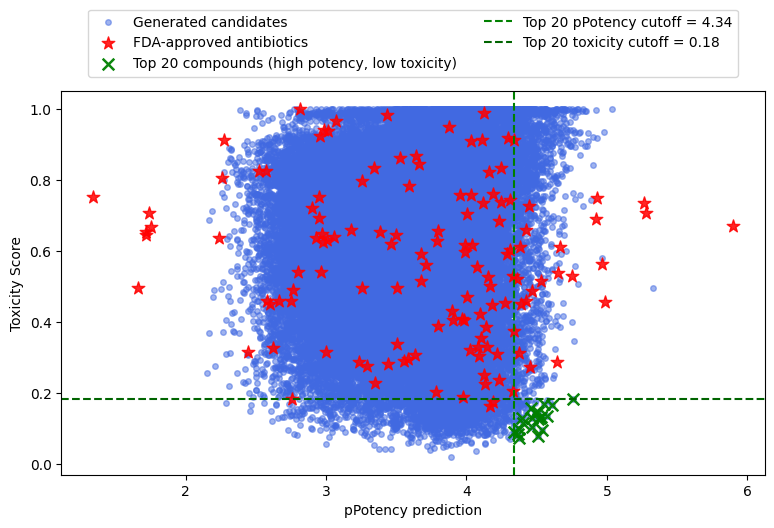

In [92]:
# Display cutoffs from the actual top 20 compounds
xDisplay = top20_2D_DF["pPotency_prediction"].min()
yDisplay = top20_2D_DF["coreToxicityScore"].max()

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    cand2DDF["pPotency_prediction"],
    cand2DDF["coreToxicityScore"],
    s=16, alpha=0.5, color="royalblue", label="Generated candidates"
)

ax.scatter(
    refScoreDF["pPotency_prediction"],
    refScoreDF["coreToxicityScore"],
    marker="*", s=90, alpha=0.85, color="red", label="FDA-approved antibiotics"
)

ax.scatter(
    top20_2D_DF["pPotency_prediction"],
    top20_2D_DF["coreToxicityScore"],
    marker="x", s=70, linewidths=1.8, alpha=0.95, color="green",
    label="Top 20 compounds (high potency, low toxicity)"
)

ax.axvline(
    xDisplay,
    linestyle="--",
    linewidth=1.5,
    color="green",
    label=f"Top 20 pPotency cutoff = {xDisplay:.2f}"
)

ax.axhline(
    yDisplay,
    linestyle="--",
    linewidth=1.5,
    color="darkgreen",
    label=f"Top 20 toxicity cutoff = {yDisplay:.2f}"
)

ax.set_xlabel("pPotency prediction")
ax.set_ylabel("Toxicity Score")

ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.90])

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_BasidalinPrecursor.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_BasidalinPrecursor.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### 15. Plot: `high pPotency`, `low Toxicity Score`, `high ADME feasibility`

Selection rule:
- pPotency in the top quartile
- Toxicity Score in the bottom quartile
- ADMEFeasibility in the top quartile

Within that region, ranking uses the unweighted geometric mean of:
- `PotencyDesRaw`
- `ToxicitySafety`
- `ADMEFeasibility`

In [93]:
cand3DDF = candScoreDF.copy()

cand3DDF = cand3DDF[
    cand3DDF[["pPotency_prediction", "coreToxicityScore", "ADMEFeasibility", "ToxicitySafety", "PotencyDesRaw"]]
    .notna()
    .all(axis=1)
].copy()

xCutoff3D = cand3DDF["pPotency_prediction"].quantile(0.75)
yCutoff3D = cand3DDF["coreToxicityScore"].quantile(0.25)
zCutoff3D = cand3DDF["ADMEFeasibility"].quantile(0.75)

optimal3DDF = cand3DDF[
    (cand3DDF["pPotency_prediction"] >= xCutoff3D) &
    (cand3DDF["coreToxicityScore"] <= yCutoff3D) &
    (cand3DDF["ADMEFeasibility"] >= zCutoff3D)
].copy()

optimal3DDF["OverallPriority3D"] = (
    optimal3DDF["PotencyDesRaw"] *
    optimal3DDF["ToxicitySafety"] *
    optimal3DDF["ADMEFeasibility"]
) ** (1 / 3)

top20_3D_DF = optimal3DDF.sort_values(
    by=["OverallPriority3D", "pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"],
    ascending=[False, False, True, False]
).head(20).copy()

top20_3D_DF["Top20Rank_3D"] = np.arange(1, len(top20_3D_DF) + 1)

top20_3D_DF[
    [
        "Top20Rank_3D",
        "smiles",
        "pPotency_prediction",
        "pPotency_std",
        "pPotency_lower_95CI",
        "coreToxicityScore",
        "ADMEFeasibility",
        "ToxicitySafety",
        "OverallPriority3D",
        "QED",
    ]
]

,Top20Rank_3D,smiles,pPotency_prediction,pPotency_std,pPotency_lower_95CI,coreToxicityScore,ADMEFeasibility,ToxicitySafety,OverallPriority3D,QED
40436,1,CC[C@](C)(CC(O)=CCNC(N)=[NH2+])C(=O)O,4.534401,1.119705,2.339779,0.093844,0.909985,0.906156,0.910926,0.227121
43371,2,C=CC[C@](CNC(N)=[NH2+])(CC(=C)O)C(=O)O,4.511873,1.118982,2.318669,0.078223,0.893079,0.921777,0.907906,0.161400
48415,3,CC[C@@](O)(CC(=O)O)C(O)=CCC(N)=O,4.372450,1.119070,2.179073,0.073134,0.939425,0.926866,0.904012,0.463501
49523,4,CC[C@@](C)(C=C(O)CCC(=O)O)C(N)=O,4.368347,1.119058,2.174994,0.084021,0.932976,0.915979,0.898394,0.579173
4465,5,C=C(O)C[C@@](CC)(OC)C(=O)O,4.319544,1.118832,2.126633,0.082931,0.965591,0.917069,0.895368,0.616822
49532,6,C[C@@H](CC(O)=CCC(N)=O)C(=O)O,4.350161,1.118645,2.157616,0.099503,0.934465,0.900497,0.891110,0.542512
4762,7,C=C(O)C[C@](C)(CC)C(=O)O,4.401008,1.119220,2.207337,0.114760,0.908709,0.885240,0.888253,0.614596
43526,8,C=CC[C@](C)(CC(O)=CCNC(N)=[NH2+])C(=O)O,4.463594,1.119450,2.269472,0.104154,0.862754,0.895846,0.886539,0.172212
40260,9,CC(C)(CC(O)=CCNC(N)=[NH2+])C(=O)O,4.488971,1.119153,2.295432,0.143259,0.877232,0.856741,0.880759,0.219552
43352,10,C=C(O)C[C@H](CC(=C)CNC(N)=[NH2+])C(=O)O,4.570368,1.119429,2.376288,0.133679,0.859715,0.866321,0.880538,0.161400


### 16. plot: pPotency vs Toxicity Score vs ADME feasibility

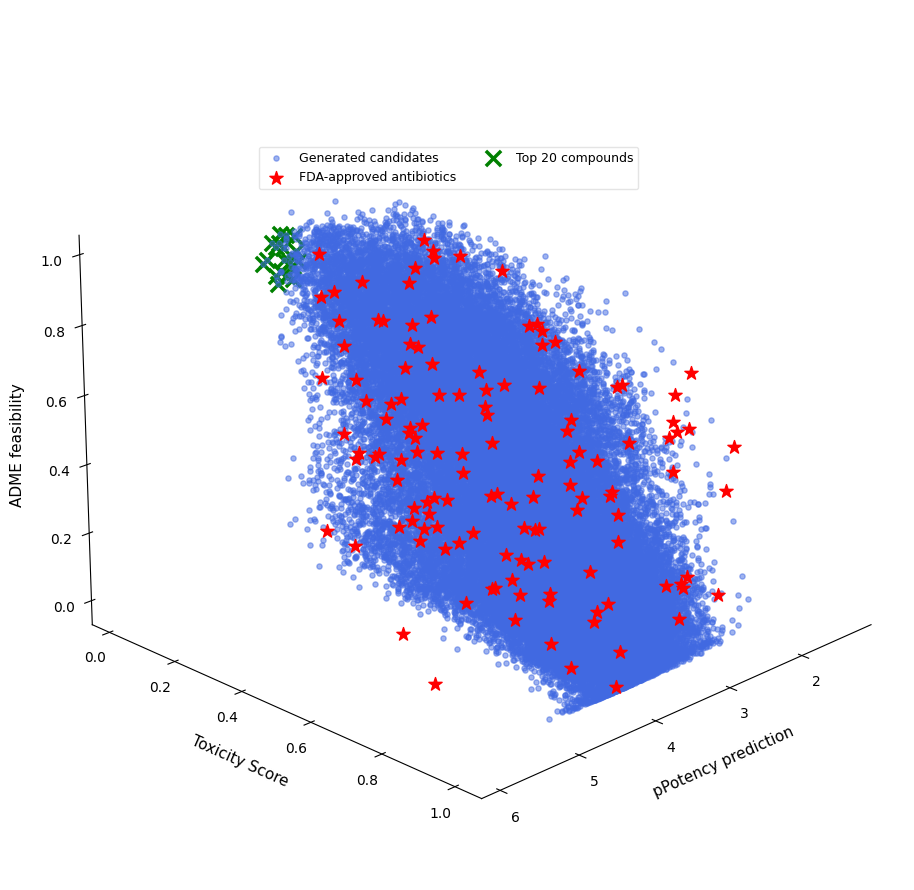

In [94]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(13, 10))
ax  = fig.add_subplot(111, projection="3d")

fig.patch.set_alpha(0.0)
ax.set_facecolor((0, 0, 0, 0))

for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
    pane.fill = False
    pane.set_edgecolor("lightgray")
    pane.set_alpha(0.0)

ax.grid(False)
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"]["linewidth"] = 0
    axis.label.set_color("k")
    axis.set_tick_params(colors="k")

ax.scatter(
    cand3DDF["pPotency_prediction"], cand3DDF["coreToxicityScore"], cand3DDF["ADMEFeasibility"],
    s=14, alpha=0.5, color="royalblue", label="Generated candidates", depthshade=False,
)
ax.scatter(
    refScoreDF["pPotency_prediction"], refScoreDF["coreToxicityScore"], refScoreDF["ADMEFeasibility"],
    marker="*", s=100, alpha=1.0, color="red", label="FDA-approved antibiotics", depthshade=False,
)
ax.scatter(
    top20_3D_DF["pPotency_prediction"], top20_3D_DF["coreToxicityScore"], top20_3D_DF["ADMEFeasibility"],
    marker="x", s=120, linewidths=2.5, alpha=1.0, color="green", label="Top 20 compounds", depthshade=False,
)

xCutoff = top20_3D_DF["pPotency_prediction"].min()
yCutoff = top20_3D_DF["coreToxicityScore"].max()
zCutoff = top20_3D_DF["ADMEFeasibility"].min()

xMin, xMax = ax.get_xlim()
yMin, yMax = ax.get_ylim()
zMin, zMax = ax.get_zlim()

#cutoffStyle = dict(linewidth=1.8, linestyle="--", alpha=0.85)
#ax.plot([xMin,    xCutoff], [yCutoff, yCutoff], [zCutoff, zCutoff], color="green",     label=f"pPotency cutoff = {xCutoff:.2f}", **cutoffStyle)
#ax.plot([xCutoff, xCutoff], [yCutoff, yMax],    [zCutoff, zCutoff], color="darkolivegreen", label=f"Toxicity cutoff = {yCutoff:.2f}", **cutoffStyle)
#ax.plot([xCutoff, xCutoff], [yCutoff, yCutoff], [zMin,    zCutoff], color="seagreen",  label=f"ADME cutoff = {zCutoff:.2f}",    **cutoffStyle)
#ax.scatter([xCutoff], [yCutoff], [zCutoff], marker="D", s=180, color="gold", edgecolors="darkorange", linewidths=1.5, zorder=10, label="Optimal cutoff corner", depthshade=False)

ax.set_xlabel("pPotency prediction", labelpad=10, color="k", fontsize=11)
ax.set_ylabel("Toxicity Score", labelpad=10, color="k", fontsize=11)
ax.set_zlabel("ADME feasibility",    labelpad=10, color="k", fontsize=11)
ax.set_zlabel("")
ax.text2D(-0.02, 0.5, "ADME feasibility", transform=ax.transAxes, fontsize=11, color="k", rotation=90, va="center", ha="center")

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.set_tick_params(colors="k", labelsize=10)

ax.view_init(elev=22, azim=45)
ax.legend(loc="upper left", bbox_to_anchor=(0.25, 0.85), ncol=2, frameon=True, framealpha=0.3, facecolor="white", edgecolor="darkgray", labelcolor="black", fontsize=9)
fig.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.05)

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_3d_BasidalinPrecursor.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_3d_BasidalinPrecursor.png")
plt.savefig(svg_path, format="svg", dpi=600, transparent=True, pad_inches=0.5)
plt.savefig(png_path, format="png", dpi=600, transparent=True, pad_inches=0.5)
plt.show()

### 17. Custom projected 3D plot for presentation

This is a presentation-oriented 2D projection of 3 variables.

Projected axes:
- horizontal right = `pPotency`
- vertical up = `Toxicity Score`
- diagonal lower-left = `ADME feasibility`

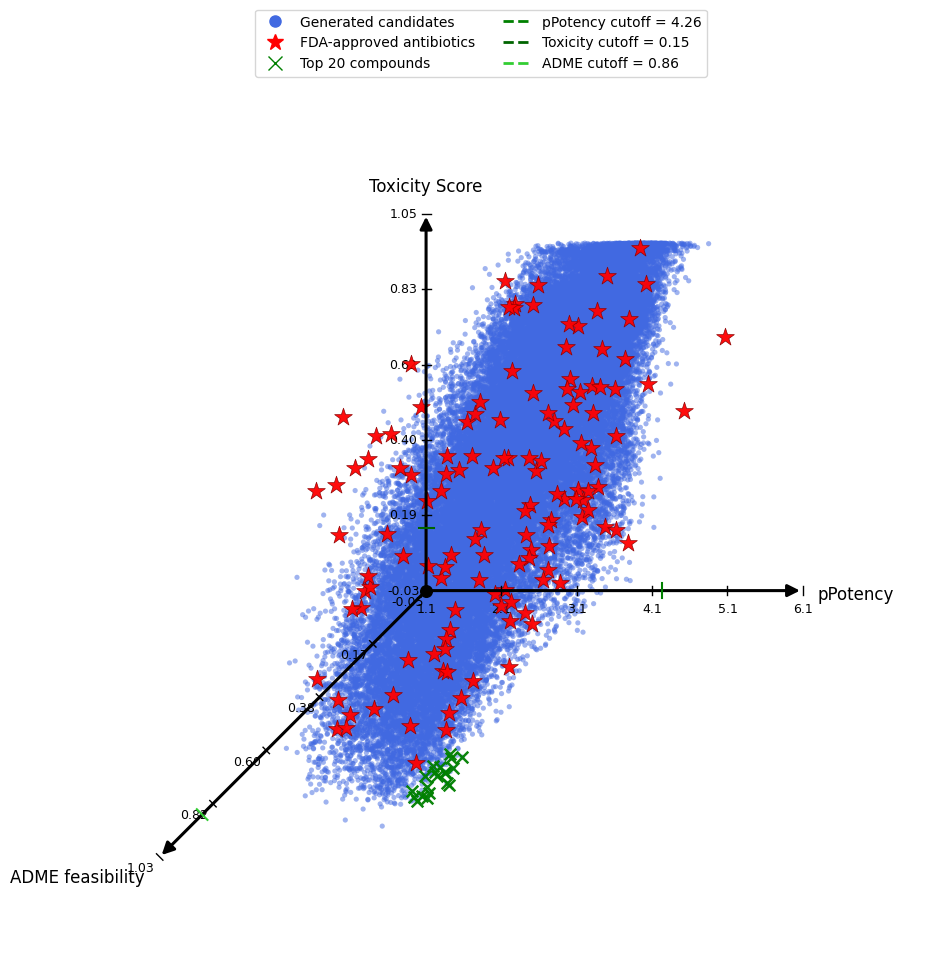

In [95]:
xCol, yCol, zCol = "pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"
cols = [xCol, yCol, zCol]

allPlotDF = cand3DDF[cols][np.isfinite(cand3DDF[cols]).all(axis=1)].copy()
refPlotDF = refScoreDF[cols][np.isfinite(refScoreDF[cols]).all(axis=1)].copy()
topPlotDF = top20_3D_DF[cols][np.isfinite(top20_3D_DF[cols]).all(axis=1)].copy()

def paddedRange(arr, frac=0.05):
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    pad = (hi - lo) * frac if (hi - lo) > 0 else 1.0
    return lo - pad, hi + pad

combined          = pd.concat([allPlotDF, refPlotDF, topPlotDF])
(X_MIN, X_MAX), (Y_MIN, Y_MAX), (Z_MIN, Z_MAX) = [paddedRange(combined[c]) for c in cols]

O  = np.zeros(2)
UX = np.array([1.0, 0.0])
UY = np.array([0.0, 1.0])
UZ = np.array([math.cos(math.radians(225)), math.sin(math.radians(225))])

def project(x, y, z):
    return O + ((x-X_MIN)/(X_MAX-X_MIN))*UX + ((y-Y_MIN)/(Y_MAX-Y_MIN))*UY + ((z-Z_MIN)/(Z_MAX-Z_MIN))*UZ

def projectDF(df):
    pts = np.array([project(r[xCol], r[yCol], r[zCol]) for _, r in df.iterrows()])
    return pts[:, 0], pts[:, 1]

allCX, allCY = projectDF(allPlotDF)
refCX, refCY = projectDF(refPlotDF)
topCX, topCY = projectDF(topPlotDF)

TIP_X, TIP_Y, TIP_Z = O + UX, O + UY, O + UZ

fig, ax = plt.subplots(figsize=(12, 11), facecolor="white")
ax.set(facecolor="white", aspect="equal")
ax.axis("off")

for tip in [TIP_X, TIP_Y, TIP_Z]:
    ax.annotate("", xy=tip, xytext=O, zorder=5,
                arrowprops=dict(arrowstyle="-|>", color="black", lw=2.2, mutation_scale=18))

ax.scatter(*O, s=70, c="black", zorder=6)

def drawTicks(unitVec, valMin, valMax, offset, nTicks=5, fmt="{:.2f}"):
    perp = np.array([unitVec[1], -unitVec[0]])
    perp /= np.linalg.norm(perp)
    for i in range(nTicks + 1):
        t, pos = i / nTicks, O + (i / nTicks) * unitVec
        ax.plot(*zip(pos - 0.012*perp, pos + 0.012*perp), color="black", lw=1.0, zorder=5)
        ax.text(*(pos + offset), fmt.format(valMin + t*(valMax-valMin)), fontsize=9, ha="center", va="center")

drawTicks(UX, X_MIN, X_MAX, np.array([ 0.00, -0.05]), fmt="{:.1f}")
drawTicks(UY, Y_MIN, Y_MAX, np.array([-0.06,  0.00]))
drawTicks(UZ, Z_MIN, Z_MAX, np.array([-0.05, -0.03]))

ax.scatter(allCX, allCY, color="royalblue", s=14,  alpha=0.5,  edgecolors="none", zorder=2)
ax.scatter(refCX, refCY, color="red",       s=180, alpha=0.95, marker="*", edgecolors="darkred", linewidths=0.5, zorder=4)
ax.scatter(topCX, topCY, color="green",     s=70,  alpha=0.95, marker="x", linewidths=1.8, zorder=5)

xCut, yCut, zCut = topPlotDF[xCol].min(), topPlotDF[yCol].max(), topPlotDF[zCol].min()
tickLen = 0.02

UZ_perp = np.array([-UZ[1], UZ[0]]) 
UZ_perp /= np.linalg.norm(UZ_perp)           
zPt = O + ((zCut-Z_MIN)/(Z_MAX-Z_MIN))*UZ 

for pt, color, dx, dy in [
    (O + ((xCut-X_MIN)/(X_MAX-X_MIN))*UX, "green", 0, tickLen),
    (O + ((yCut-Y_MIN)/(Y_MAX-Y_MIN))*UY, "darkgreen",  tickLen, 0),
]:
    ax.plot([pt[0]-dx, pt[0]+dx], [pt[1]-dy, pt[1]+dy], color=color, lw=1.5, zorder=5)

# Z cutoff tick perpendicular to UZ
ax.plot(
    [zPt[0] - tickLen*UZ_perp[0], zPt[0] + tickLen*UZ_perp[0]],
    [zPt[1] - tickLen*UZ_perp[1], zPt[1] + tickLen*UZ_perp[1]],
    color="limegreen", lw=1.5, zorder=5
)

ax.text(TIP_X[0]+0.04, TIP_X[1]-0.01, "pPotency",            fontsize=12, ha="left",   va="center")
ax.text(TIP_Y[0],      TIP_Y[1]+0.05, "Toxicity Score",  fontsize=12, ha="center", va="bottom")
ax.text(TIP_Z[0]-0.04, TIP_Z[1]-0.03, "ADME feasibility",    fontsize=12, ha="right",  va="top")

allPx = np.concatenate([allCX, refCX, topCX, [TIP_X[0], TIP_Y[0], TIP_Z[0]]])
allPy = np.concatenate([allCY, refCY, topCY, [TIP_X[1], TIP_Y[1], TIP_Z[1]]])
ax.set_xlim(allPx.min()-0.3, allPx.max()+0.3)
ax.set_ylim(allPy.min()-0.3, allPy.max()+0.3)

handles = [
    mlines.Line2D([], [], color="royalblue", marker="o", linestyle="None", markersize=8, label="Generated candidates"),
    mlines.Line2D([], [], color="red",       marker="*", linestyle="None", markersize=12, label="FDA-approved antibiotics"),
    mlines.Line2D([], [], color="green",     marker="x", linestyle="None", markersize=10, label="Top 20 compounds"),
    mlines.Line2D([], [], color="green",     linestyle="--", lw=2, label=f"pPotency cutoff = {xCut:.2f}"),
    mlines.Line2D([], [], color="darkgreen", linestyle="--", lw=2, label=f"Toxicity cutoff = {yCut:.2f}"),
    mlines.Line2D([], [], color="limegreen", linestyle="--", lw=2, label=f"ADME cutoff = {zCut:.2f}"),
]
ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_BasidalinPrecursor.svg"), format="svg", dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_BasidalinPrecursor.png"), format="png", dpi=600, bbox_inches="tight", facecolor="white")
plt.show()

### 18. Save the top 20 candidates

In [96]:
top20_2D_cols = ["Top20Rank_2D", "smiles", "pPotency_prediction", "pPotency_std", "pPotency_lower_95CI", "pPotency_upper_95CI", "coreToxicityScore", "ToxicitySafety", "OverallPriority2D", "QED"]
top20_3D_cols = ["Top20Rank_3D", "smiles", "pPotency_prediction", "pPotency_std", "pPotency_lower_95CI", "pPotency_upper_95CI", "coreToxicityScore", "ADMEFeasibility", "ToxicitySafety", "OverallPriority3D", "QED"]

toxicityTop20Path = os.path.join(saveDir, f"{target_organism}_potency_coreToxicity_top20_BasidalinPrecursor.csv")
admetTop20Path    = os.path.join(saveDir, f"{target_organism}_potency_coreToxicity_adme_top20_BasidalinPrecursor.csv")

top20_2D_DF[top20_2D_cols[1:]].to_csv(toxicityTop20Path, index=False)
top20_3D_DF[top20_3D_cols[1:]].to_csv(admetTop20Path,    index=False)

print(f"Saved:\n- {toxicityTop20Path}\n- {admetTop20Path}")

#display(top20_2D_DF[top20_2D_cols])
#display(top20_3D_DF[top20_3D_cols])

Saved:
- /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB/BacillusAnthracis_potency_coreToxicity_top20_BasidalinPrecursor.csv
- /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB/BacillusAnthracis_potency_coreToxicity_adme_top20_BasidalinPrecursor.csv
